# Juvenile Mortality Modeling Lab

This notebook is set up as a practical actuarial lab for **juvenile mortality modeling**.
The intent is not just to fit models, but to produce results that are stable enough to compare, explain, and carry into a report.

It is organized into four sessions:

1. **Data overview and scope**
2. **Feature screening**
3. **Mortality model fitting and comparison**
4. **Validation and sheet-style mortality output**

### Working style
This notebook still avoids heavy automation.
You can change filters, formulas, feature sets, or comment out blocks without breaking the lab structure.

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import statsmodels.api as sm
import statsmodels.formula.api as smf
from IPython.display import display
from patsy.builtins import bs

warnings.filterwarnings("default")
warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")
np.set_printoptions(suppress=True, linewidth=140)

try:
    import duckdb
    HAS_DUCKDB = True
except Exception:
    HAS_DUCKDB = False

try:
    import pyarrow  # noqa: F401
    HAS_PYARROW = True
except Exception:
    HAS_PYARROW = False

try:
    from sklearn.ensemble import (
        ExtraTreesRegressor,
        GradientBoostingRegressor,
        HistGradientBoostingRegressor,
        RandomForestRegressor,
    )
    from sklearn.inspection import permutation_importance
    from sklearn.linear_model import PoissonRegressor
    HAS_SKLEARN = True
except Exception:
    HAS_SKLEARN = False

print("duckdb available :", HAS_DUCKDB)
print("pyarrow available:", HAS_PYARROW)
print("sklearn available:", HAS_SKLEARN)


duckdb available : True
pyarrow available: True
sklearn available: True


---

# Session 1 · Data overview, scope, and first-pass actuarial review


In [45]:
# ============================================================
# CONTROL PANEL — EDIT HERE FIRST
# ============================================================

DATA_PATH = Path("script/data/parquet/full.parquet")

# ------------------------------
# Core scope filters
# ------------------------------
OBSERVATION_YEARS = None          # Example: [2018, 2019]; use None to keep all years
ISSUE_AGE_MIN = 0
ISSUE_AGE_MAX = 17
ATTAINED_AGE_MIN = 1
ATTAINED_AGE_MAX = 94
DURATION_MIN = 1
DURATION_CAP = 119

AGE_IND_KEEP = None               # Example: ["0"] or ["1"]; None keeps all age bases
SEX_KEEP = None                   # Example: ["M"] or ["F"]; None keeps all sexes
SMOKER_STATUS_KEEP = ["U"]        # Example: ["U"]; set to None to keep all
INSURANCE_PLAN_DROP = ["Other"]   # Set to [] if you want to keep "Other"

EXCLUDE_POST_LEVEL_TERM = True
POST_LEVEL_TERM_EXCLUDE_VALUES = ["PLT"]

# Optional duration cleanup for summary work only.
# Keep FALSE if you want sheet-style outputs similar to the reference tables.
COLLAPSE_DURATION_26_PLUS = False

# ------------------------------
# 1M face-amount cap option
# ------------------------------
CAP_FACE_AT_1M = True
FACE_CAP_VALUE = 1_000_000
FACE_CAP_SOURCE_BANDS = [
    "08: 1,000,000 - 2,499,999",
    "09: 2,500,000 - 4,999,999",
    "10: 5,000,000 - 9,999,999",
    "11: 10,000,000+",
]
FACE_CAP_TARGET_BAND = "08: 1,000,000+"

# ------------------------------
# Metric columns
# ------------------------------

# ------------------------------
# Age-basis harmonized helper columns used for testing / modeling
# Raw Issue_Age / Attained_Age are still retained for scope and display.
# ------------------------------
ISSUE_AGE_MOD_COL = "Issue_Age_mod"
ATTAINED_AGE_MOD_COL = "Attained_Age_mod"
ISSUE_AGE_MOD_MAX = ISSUE_AGE_MAX + 0.5
ATTAINED_AGE_MOD_MAX = ATTAINED_AGE_MAX + 0.5

# ------------------------------
# Optional maturity-normalized exposure scaling for later issue years.
# This only rescales exposed policies / amount for descriptive rate work.
# Deaths and expected deaths are not changed.
# ------------------------------
APPLY_ISSUE_YEAR_EXPOSURE_SCALING = True
ISSUE_YEAR_EXPOSURE_TARGET_YEARS = 7
ISSUE_YEAR_EXPOSURE_FULL_CREDIT_START = 2013
ISSUE_YEAR_EXPOSURE_SCALE_START = 2014
ISSUE_YEAR_EXPOSURE_SCALE_END = 2019

ACTUAL_CNT_COL = "Death_Count"
EXPECTED_CNT_COL = "ExpDth_VBT2015_Cnt"
ACTUAL_AMT_COL = "Death_Claim_Amount"
EXPECTED_AMT_COL = "ExpDth_VBT2015_Amt"

NUMERIC_COLS = [
    "Observation_Year", "Issue_Age", ISSUE_AGE_MOD_COL, "Duration", "Issue_Year", "Attained_Age", ATTAINED_AGE_MOD_COL,
    "Amount_Exposed", "Policies_Exposed", ACTUAL_AMT_COL, ACTUAL_CNT_COL,
    EXPECTED_CNT_COL, EXPECTED_AMT_COL
]

RAW_CATEGORICAL_COLS = [
    "Age_Ind", "Sex", "Smoker_Status", "Insurance_Plan", "Face_Amount_Band",
    "SOA_Antp_Lvl_TP", "SOA_Guar_Lvl_TP", "SOA_Post_Lvl_Ind", "Slct_Ult_Ind",
    "Preferred_Indicator", "Number_of_Pfd_Classes", "Preferred_Class"
]

DERIVED_CATEGORICAL_COLS = [
    "Insurance_Plan_Group",
    "Face_Band_Group",
    "Issue_Age_Band",
    "Attained_Age_Band",
    "Duration_Band",
]

CATEGORICAL_COLS = RAW_CATEGORICAL_COLS + DERIVED_CATEGORICAL_COLS
BASE_COLUMNS = [
    "Observation_Year",
    "Issue_Age",
    "Duration",
    "Issue_Year",
    "Attained_Age",
    "Amount_Exposed",
    "Policies_Exposed",
    ACTUAL_AMT_COL,
    ACTUAL_CNT_COL,
    EXPECTED_CNT_COL,
    EXPECTED_AMT_COL,
] + RAW_CATEGORICAL_COLS

# ------------------------------
# Development sampling controls
# Default is full data. These are only for faster exploratory work.
# ------------------------------
DEVELOPMENT_SAMPLE_FRACTION = None     # Example: 0.30 for a 30% stratified development sample
DEVELOPMENT_SAMPLE_STRATA = ["Observation_Year", "Age_Ind", "Sex", "Issue_Age_Band", "Duration_Band"]
DEVELOPMENT_SAMPLE_RANDOM_STATE = 42

# ------------------------------
# Grouping choices for challenger diagnostics
# ------------------------------
PLAN_GROUP_MAP = {
    "Perm": "Perm",
    "Term": "Term",
    "UL": "UL/VL Family",
    "ULSG": "UL/VL Family",
    "VL": "UL/VL Family",
    "VLSG": "UL/VL Family",
    "Other": "Other/Unknown",
    "Missing": "Missing",
}

FACE_BAND_GROUP_MAP = {
    "01: 0 - 9,999": "01-03: <50k",
    "02: 10,000 - 24,999": "01-03: <50k",
    "03: 25,000 - 49,999": "01-03: <50k",
    "04: 50,000 - 99,999": "04-05: 50k-249k",
    "05: 100,000 - 249,999": "04-05: 50k-249k",
    "06: 250,000 - 499,999": "06-07: 250k-999k",
    "07: 500,000 - 999,999": "06-07: 250k-999k",
    "08: 1,000,000 - 2,499,999": "08+: 1M+",
    "08: 1,000,000+": "08+: 1M+",
    "09: 2,500,000 - 4,999,999": "08+: 1M+",
    "10: 5,000,000 - 9,999,999": "08+: 1M+",
    "11: 10,000,000+": "08+: 1M+",
    "Missing": "Missing",
}

# ------------------------------
# Session 2: screening controls
# ------------------------------
SCREEN_FEATURES = [
    "Age_Ind",
    "Sex",
    "Insurance_Plan",
    "Insurance_Plan_Group",
    "Face_Amount_Band",
    "Face_Band_Group",
    "Slct_Ult_Ind",
    "Preferred_Indicator",
    "Number_of_Pfd_Classes",
    ISSUE_AGE_MOD_COL,
    ATTAINED_AGE_MOD_COL,
    "Duration",
    "Observation_Year",
    "SOA_Guar_Lvl_TP",
    "SOA_Antp_Lvl_TP",
    "SOA_Post_Lvl_Ind",
]
NUMERIC_SCREEN_FEATURES = [ISSUE_AGE_MOD_COL, ATTAINED_AGE_MOD_COL, "Duration", "Observation_Year"]
SCREEN_SPLINE_DF = 6
SCREEN_TARGET_SMOOTH = 0.25
SCREEN_RANDOM_STATE = 42
CORRELATION_WEIGHT_COL = "Policies_Exposed"

NUMERIC_CORR_FEATURES = [ISSUE_AGE_MOD_COL, ATTAINED_AGE_MOD_COL, "Duration", "Observation_Year"]
CATEGORICAL_ASSOC_FEATURES = [
    "Age_Ind",
    "Sex",
    "Insurance_Plan",
    "Insurance_Plan_Group",
    "Face_Amount_Band",
    "Face_Band_Group",
    "Slct_Ult_Ind",
]

TWO_WAY_AE_PAIRS = [
    ("Issue_Age_Band", "Duration_Band"),
    ("Attained_Age_Band", "Duration_Band"),
    ("Insurance_Plan_Group", "Face_Band_Group"),
    ("Age_Ind", "Sex"),
]

# Manual shortlist after screening.
SHORTLIST_FEATURES = [
    "Age_Ind",
    "Sex",
    "Issue_Age",
    "Duration",
]

# ------------------------------
# Session 3: GAM-style candidate controls
# Holdout is intentionally inactive in this reporting build.
# ------------------------------
USE_HOLDOUT = False

GAM_ISSUE_AGE_KNOTS = [1, 5, 10, 15]
GAM_DURATION_KNOTS = [1, 5, 10, 15, 20, 25]
GAM_ATTAINED_AGE_KNOTS = [5, 10, 15, 25, 40, 60]
GAM_DURATION_UPPER_BOUND = 26

GLM_FORMULA_FACTOR_SPLINE = (
    f"{ACTUAL_CNT_COL} ~ C(Age_Ind) + C(Sex) + C(Insurance_Plan) + C(Face_Amount_Band) "
    f"+ C(Slct_Ult_Ind) "
    f"+ bs(Issue_Age_mod, df=6, degree=3, include_intercept=False) "
    f"+ bs(Duration, df=6, degree=3, include_intercept=False)"
)

GAM_FORMULA_CORE = (
    f"{ACTUAL_CNT_COL} ~ C(Age_Ind) + C(Sex) "
    f"+ bs(Issue_Age_mod_spline, knots={tuple(GAM_ISSUE_AGE_KNOTS)}, degree=3, include_intercept=False, lower_bound={ISSUE_AGE_MIN}, upper_bound={ISSUE_AGE_MOD_MAX}) "
    f"+ bs(Duration_spline, knots={tuple(GAM_DURATION_KNOTS)}, degree=3, include_intercept=False, lower_bound=0, upper_bound={GAM_DURATION_UPPER_BOUND})"
)

GAM_FORMULA_SELECT = (
    f"{ACTUAL_CNT_COL} ~ C(Age_Ind) + C(Sex) + C(Slct_Ult_Ind) "
    f"+ bs(Issue_Age_mod_spline, knots={tuple(GAM_ISSUE_AGE_KNOTS)}, degree=3, include_intercept=False, lower_bound={ISSUE_AGE_MIN}, upper_bound={ISSUE_AGE_MOD_MAX}) "
    f"+ bs(Duration_spline, knots={tuple(GAM_DURATION_KNOTS)}, degree=3, include_intercept=False, lower_bound=0, upper_bound={GAM_DURATION_UPPER_BOUND})"
)

GAM_FORMULA_PLAN_FACE = (
    f"{ACTUAL_CNT_COL} ~ C(Age_Ind) + C(Sex) + C(Insurance_Plan_Group) + C(Face_Band_Group) + C(Slct_Ult_Ind) "
    f"+ bs(Issue_Age_mod_spline, knots={tuple(GAM_ISSUE_AGE_KNOTS)}, degree=3, include_intercept=False, lower_bound={ISSUE_AGE_MIN}, upper_bound={ISSUE_AGE_MOD_MAX}) "
    f"+ bs(Duration_spline, knots={tuple(GAM_DURATION_KNOTS)}, degree=3, include_intercept=False, lower_bound=0, upper_bound={GAM_DURATION_UPPER_BOUND})"
)

GAM_FORMULA_ATTAINED = (
    f"{ACTUAL_CNT_COL} ~ C(Age_Ind) + C(Sex) + C(Slct_Ult_Ind) "
    f"+ bs(Attained_Age_mod_spline, knots={tuple(GAM_ATTAINED_AGE_KNOTS)}, degree=3, include_intercept=False, lower_bound={ATTAINED_AGE_MIN}, upper_bound={ATTAINED_AGE_MOD_MAX}) "
    f"+ bs(Duration_spline, knots={tuple(GAM_DURATION_KNOTS)}, degree=3, include_intercept=False, lower_bound=0, upper_bound={GAM_DURATION_UPPER_BOUND})"
)

ML_FEATURES = SHORTLIST_FEATURES.copy()
MODEL_TARGET_SMOOTH = 0.25
MODEL_RANDOM_STATE = 42

# ------------------------------
# Session 4: validation / review controls
# ------------------------------
SELECTED_MODEL_KEY = "poisson_gam_attained"
SEGMENT_TOLERANCE = 0.10
MIN_EXPECTED_FOR_REVIEW = 3.0
MIN_EXPECTED_FOR_MONOTONICITY = 3.0
MONOTONICITY_RATE_COL = "Predicted_Rate_per_1000"

# ------------------------------
# Sheet-style mortality output
# ------------------------------
OUTPUT_AGE_IND = "0"              # "0" = ANB, "1" = ALB
OUTPUT_SEX = "M"                  # "M" or "F"
OUTPUT_SELECT_PERIOD = 25
OUTPUT_ULT_DURATION = 26
OUTPUT_DURATION_COLUMNS = list(range(1, 26))
OUTPUT_RATE_PER = 1000
OUTPUT_ISSUE_AGE_MIN = 0
OUTPUT_ISSUE_AGE_MAX = 17

# Optional benchmark comparison
BENCHMARK_XLSX_PATH = None        # Example: Path("2015-vbt-unismoke-alb-anb.xlsx")
BENCHMARK_SHEET_NAME = None       # Example: "2015 Male Unismoke ANB"

EXPORT_DIR = Path("script/model_outputs")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)


In [3]:
# ============================================================
# DATA DICTIONARY USED BY THIS NOTEBOOK
# ============================================================

DATA_DICTIONARY = pd.DataFrame({
    "Column": [
        "Observation_Year", "Age_Ind", "Sex", "Smoker_Status", "Insurance_Plan",
        "Issue_Age", "Issue_Age_mod", "Duration", "Issue_Year", "Attained_Age", "Attained_Age_mod",
        "Face_Amount_Band", "Amount_Exposed", "Policies_Exposed",
        ACTUAL_AMT_COL, ACTUAL_CNT_COL, EXPECTED_CNT_COL, EXPECTED_AMT_COL,
        "SOA_Antp_Lvl_TP", "SOA_Guar_Lvl_TP", "SOA_Post_Lvl_Ind", "Slct_Ult_Ind",
        "Preferred_Indicator", "Number_of_Pfd_Classes", "Preferred_Class",
        "Insurance_Plan_Group", "Face_Band_Group",
    ],
    "Meaning": [
        "Calendar year of observation",
        "Age basis indicator; kept explicit in this notebook (no basis conversion here)",
        "Sex",
        "Smoking status",
        "Insurance plan",
        "Issue age on raw company basis",
        "Issue age converted to a simple harmonized half-year basis (ALB = raw + 0.5; ANB = raw)",
        "Duration",
        "Issue year",
        "Attained age on raw company basis",
        "Attained age converted to a simple harmonized half-year basis (ALB = raw + 0.5; ANB = raw)",
        "Face amount band; optionally capped at 1M+ in this notebook",
        "Amount exposed",
        "Policies exposed",
        "Actual death claim amount",
        "Actual death count",
        "2015 VBT expected death count",
        "2015 VBT expected death amount",
        "SOA anticipated level term field",
        "SOA guaranteed level term field",
        "SOA post-level term indicator",
        "Select / ultimate indicator",
        "Preferred indicator",
        "Number of preferred classes",
        "Preferred class",
        "Derived grouped version of Insurance_Plan for challenger diagnostics",
        "Derived grouped version of Face_Amount_Band for challenger diagnostics",
    ],
})

display(DATA_DICTIONARY)


,Column,Meaning
0,Observation_Year,Calendar year of observation
1,Age_Ind,Age basis indicator; kept explicit in this not...
2,Sex,Sex
3,Smoker_Status,Smoking status
4,Insurance_Plan,Insurance plan
5,Issue_Age,Issue age on raw company basis
6,Issue_Age_mod,Issue age converted to a simple harmonized hal...
7,Duration,Duration
8,Issue_Year,Issue year
9,Attained_Age,Attained age on raw company basis


In [38]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def require_parquet_support():
    if HAS_DUCKDB or HAS_PYARROW:
        return
    raise ImportError(
        "This notebook needs either duckdb or pyarrow to read parquet. "
        "Install one of them locally, for example: pip install duckdb or pip install pyarrow"
    )


def require_sklearn():
    if HAS_SKLEARN:
        return
    raise ImportError(
        "This notebook needs scikit-learn for Sessions 2 and 3. "
        "Install it locally, for example: pip install scikit-learn"
    )


def read_parquet_data(path: Path, columns: list[str] | None = None) -> pd.DataFrame:
    require_parquet_support()

    if not path.exists():
        raise FileNotFoundError(f"Parquet file not found: {path}")

    if HAS_DUCKDB:
        cols_sql = "*" if columns is None else ", ".join([f'"{c}"' for c in columns])
        query = f"SELECT {cols_sql} FROM read_parquet('{path.as_posix()}')"
        return duckdb.sql(query).df()

    return pd.read_parquet(path, columns=columns)


def export_csv(df: pd.DataFrame, filename: str):
    path = EXPORT_DIR / filename
    df.to_csv(path, index=False)
    print(f"Saved: {path}")


def force_plain_axis(ax, axis: str = "both"):
    formatter = mtick.ScalarFormatter(useOffset=False)
    formatter.set_scientific(False)

    if axis in ("x", "both"):
        ax.xaxis.set_major_formatter(formatter)
    if axis in ("y", "both"):
        ax.yaxis.set_major_formatter(formatter)


def safe_divide(numerator, denominator):
    numerator = np.asarray(numerator, dtype=float)
    denominator = np.asarray(denominator, dtype=float)
    out = np.divide(
        numerator,
        denominator,
        out=np.full_like(numerator, np.nan, dtype=float),
        where=np.abs(denominator) > 1e-12,
    )
    if np.ndim(out) == 0:
        return float(out)
    if out.size == 1:
        return float(np.ravel(out)[0])
    return out


def standardize_frame(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    for col in NUMERIC_COLS:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")

    for col in CATEGORICAL_COLS:
        if col in out.columns:
            out[col] = out[col].astype("string").fillna("Missing")

    return out



def derive_age_basis_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    age_ind = out["Age_Ind"].astype("string").fillna("Missing")

    out[ISSUE_AGE_MOD_COL] = pd.to_numeric(out["Issue_Age"], errors="coerce")
    out[ATTAINED_AGE_MOD_COL] = pd.to_numeric(out["Attained_Age"], errors="coerce")

    alb_mask = age_ind == "1"   # ALB
    anb_mask = age_ind == "0"   # ANB

    out.loc[alb_mask, ISSUE_AGE_MOD_COL] = out.loc[alb_mask, "Issue_Age"] + 0.5
    out.loc[alb_mask, ATTAINED_AGE_MOD_COL] = out.loc[alb_mask, "Attained_Age"] + 0.5

    out.loc[anb_mask, ISSUE_AGE_MOD_COL] = out.loc[anb_mask, "Issue_Age"]
    out.loc[anb_mask, ATTAINED_AGE_MOD_COL] = out.loc[anb_mask, "Attained_Age"]

    return out


def apply_issue_year_exposure_scaling(df: pd.DataFrame) -> pd.DataFrame:
    if not APPLY_ISSUE_YEAR_EXPOSURE_SCALING:
        return df.copy()

    out = df.copy()
    issue_year = pd.to_numeric(out["Issue_Year"], errors="coerce")
    eligible = issue_year.between(ISSUE_YEAR_EXPOSURE_SCALE_START, ISSUE_YEAR_EXPOSURE_SCALE_END, inclusive="both")

    observed_years = ISSUE_YEAR_EXPOSURE_SCALE_END - issue_year + 1
    scale = np.where(
        eligible,
        ISSUE_YEAR_EXPOSURE_TARGET_YEARS / np.clip(observed_years, 1, None),
        1.0,
    )

    out["Policies_Exposed"] = pd.to_numeric(out["Policies_Exposed"], errors="coerce") * scale
    out["Amount_Exposed"] = pd.to_numeric(out["Amount_Exposed"], errors="coerce") * scale
    return out


def apply_face_amount_cap_1m(df: pd.DataFrame) -> pd.DataFrame:
    if not CAP_FACE_AT_1M:
        return df.copy()

    out = df.copy()
    mask = out["Face_Amount_Band"].isin(FACE_CAP_SOURCE_BANDS)

    out.loc[mask, "Face_Amount_Band"] = FACE_CAP_TARGET_BAND
    out.loc[mask, ACTUAL_AMT_COL] = FACE_CAP_VALUE * out.loc[mask, ACTUAL_CNT_COL]
    out.loc[mask, "Amount_Exposed"] = FACE_CAP_VALUE * out.loc[mask, "Policies_Exposed"]
    out.loc[mask, EXPECTED_AMT_COL] = FACE_CAP_VALUE * out.loc[mask, EXPECTED_CNT_COL]

    return out


def add_grouped_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    if "Insurance_Plan" in out.columns:
        out["Insurance_Plan_Group"] = (
            out["Insurance_Plan"]
            .astype("string")
            .fillna("Missing")
            .map(PLAN_GROUP_MAP)
            .fillna(out["Insurance_Plan"].astype("string").fillna("Missing"))
            .astype("string")
        )

    if "Face_Amount_Band" in out.columns:
        out["Face_Band_Group"] = (
            out["Face_Amount_Band"]
            .astype("string")
            .fillna("Missing")
            .map(FACE_BAND_GROUP_MAP)
            .fillna(out["Face_Amount_Band"].astype("string").fillna("Missing"))
            .astype("string")
        )

    return out


def add_validation_bands(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    issue_age_series = out[ISSUE_AGE_MOD_COL] if ISSUE_AGE_MOD_COL in out.columns else out["Issue_Age"]
    attained_age_series = out[ATTAINED_AGE_MOD_COL] if ATTAINED_AGE_MOD_COL in out.columns else out["Attained_Age"]

    out["Issue_Age_Band"] = pd.cut(
        issue_age_series,
        bins=[-0.1, 0.5, 5.5, 10.5, 15.5, 17.5],
        labels=["0", "1-5", "6-10", "11-15", "16-17"],
        include_lowest=True,
        right=True,
    )

    attained_min = int(np.floor(attained_age_series.min())) if len(out) else 0
    attained_floor = max(0, (attained_min // 5) * 5)
    attained_bins = list(range(attained_floor, 101, 5))
    if attained_bins[-1] < 100:
        attained_bins.append(100)

    out["Attained_Age_Band"] = pd.cut(
        attained_age_series,
        bins=attained_bins,
        include_lowest=True,
        right=False,
    )

    out["Duration_Band"] = pd.cut(
        np.where(out["Duration"] >= 26, 26, out["Duration"]),
        bins=[-0.1, 1, 5, 10, 15, 20, 26],
        labels=["0-1", "2-5", "6-10", "11-15", "16-20", "21-26+"],
        include_lowest=True,
        right=True,
    )
    return out


def apply_scope_filters(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    out = standardize_frame(df)
    steps = [{"step": "raw_input", "rows": len(out)}]

    if OBSERVATION_YEARS is not None:
        out = out[out["Observation_Year"].isin(OBSERVATION_YEARS)].copy()
        steps.append({"step": f"Observation_Year in {OBSERVATION_YEARS}", "rows": len(out)})

    out = out[
        out["Issue_Age"].between(ISSUE_AGE_MIN, ISSUE_AGE_MAX, inclusive="both")
    ].copy()
    steps.append({"step": f"Issue_Age between {ISSUE_AGE_MIN} and {ISSUE_AGE_MAX}", "rows": len(out)})

    if ATTAINED_AGE_MIN is not None:
        out = out[out["Attained_Age"] >= ATTAINED_AGE_MIN].copy()
        steps.append({"step": f"Attained_Age >= {ATTAINED_AGE_MIN}", "rows": len(out)})

    if ATTAINED_AGE_MAX is not None:
        out = out[out["Attained_Age"] <= ATTAINED_AGE_MAX].copy()
        steps.append({"step": f"Attained_Age <= {ATTAINED_AGE_MAX}", "rows": len(out)})

    if AGE_IND_KEEP is not None:
        out = out[out["Age_Ind"].isin(AGE_IND_KEEP)].copy()
        steps.append({"step": f"Age_Ind in {AGE_IND_KEEP}", "rows": len(out)})

    if SEX_KEEP is not None:
        out = out[out["Sex"].isin(SEX_KEEP)].copy()
        steps.append({"step": f"Sex in {SEX_KEEP}", "rows": len(out)})

    if SMOKER_STATUS_KEEP is not None:
        out = out[out["Smoker_Status"].isin(SMOKER_STATUS_KEEP)].copy()
        steps.append({"step": f"Smoker_Status in {SMOKER_STATUS_KEEP}", "rows": len(out)})

    if INSURANCE_PLAN_DROP:
        out = out[~out["Insurance_Plan"].isin(INSURANCE_PLAN_DROP)].copy()
        steps.append({"step": f"Insurance_Plan not in {INSURANCE_PLAN_DROP}", "rows": len(out)})

    if EXCLUDE_POST_LEVEL_TERM:
        out = out[~out["SOA_Post_Lvl_Ind"].isin(POST_LEVEL_TERM_EXCLUDE_VALUES)].copy()
        steps.append({"step": f"SOA_Post_Lvl_Ind not in {POST_LEVEL_TERM_EXCLUDE_VALUES}", "rows": len(out)})

    if COLLAPSE_DURATION_26_PLUS:
        out["Duration"] = np.where(out["Duration"] >= 26, 26, out["Duration"])
        steps.append({"step": "Duration >= 26 collapsed to 26", "rows": len(out)})

    out = out[out[EXPECTED_CNT_COL] > 0].copy()
    steps.append({"step": f"{EXPECTED_CNT_COL} > 0", "rows": len(out)})

    out = apply_face_amount_cap_1m(out)
    if CAP_FACE_AT_1M:
        steps.append({"step": "Applied 1M face cap rule", "rows": len(out)})

    out = derive_age_basis_columns(out)
    steps.append({"step": "Added Issue_Age_mod / Attained_Age_mod (ALB = raw + 0.5; ANB = raw)", "rows": len(out)})

    out = apply_issue_year_exposure_scaling(out)
    if APPLY_ISSUE_YEAR_EXPOSURE_SCALING:
        steps.append({"step": "Scaled Policies_Exposed / Amount_Exposed for later issue years to a 7-year maturity basis", "rows": len(out)})

    out = add_grouped_features(out)
    out = add_validation_bands(out)
    steps.append({"step": "Added grouped plan / face-band fields and validation bands", "rows": len(out)})

    return out.reset_index(drop=True), pd.DataFrame(steps)


def apply_optional_development_sample(
    df: pd.DataFrame,
    fraction: float | None = None,
    strata: list[str] | None = None,
    random_state: int = 42,
) -> pd.DataFrame:
    if fraction is None:
        return df.copy()

    if not (0 < fraction <= 1):
        raise ValueError("DEVELOPMENT_SAMPLE_FRACTION must be in (0, 1].")

    if math.isclose(fraction, 1.0):
        return df.copy()

    work = df.copy()
    strata = [c for c in (strata or []) if c in work.columns]

    if not strata:
        return work.sample(frac=fraction, random_state=random_state).reset_index(drop=True)

    pieces = []
    for _, sub in work.groupby(strata, dropna=False, sort=False):
        n_take = max(1, int(round(len(sub) * fraction)))
        n_take = min(n_take, len(sub))
        pieces.append(sub.sample(n=n_take, random_state=random_state))

    sampled = pd.concat(pieces, ignore_index=True)
    return sampled.reset_index(drop=True)


def overall_metrics(df: pd.DataFrame) -> pd.DataFrame:
    actual_cnt = float(df[ACTUAL_CNT_COL].sum())
    expected_cnt = float(df[EXPECTED_CNT_COL].sum())
    actual_amt = float(df[ACTUAL_AMT_COL].sum())
    expected_amt = float(df[EXPECTED_AMT_COL].sum())
    policies = float(df["Policies_Exposed"].sum())
    amount_exposed = float(df["Amount_Exposed"].sum())

    return pd.DataFrame({
        "Metric": [
            "Rows",
            "Policies Exposed",
            "Amount Exposed",
            "Death Count",
            "Expected Death Count",
            "A/E Count",
            "Death Claim Amount",
            "Expected Death Amount",
            "A/E Amount",
            "Actual Rate per 1000",
            "Expected Rate per 1000",
        ],
        "Value": [
            len(df),
            policies,
            amount_exposed,
            actual_cnt,
            expected_cnt,
            safe_divide(actual_cnt, expected_cnt),
            actual_amt,
            expected_amt,
            safe_divide(actual_amt, expected_amt),
            safe_divide(actual_cnt * 1000.0, policies),
            safe_divide(expected_cnt * 1000.0, policies),
        ]
    })


def ae_summary(df: pd.DataFrame, group_cols: str | list[str]) -> pd.DataFrame:
    if isinstance(group_cols, str):
        group_cols = [group_cols]

    out = (
        df.groupby(group_cols, dropna=False)[
            [ACTUAL_CNT_COL, EXPECTED_CNT_COL, ACTUAL_AMT_COL, EXPECTED_AMT_COL, "Policies_Exposed", "Amount_Exposed"]
        ]
        .sum()
        .reset_index()
        .sort_values(group_cols)
        .reset_index(drop=True)
    )
    out["A/E_Count"] = safe_divide(out[ACTUAL_CNT_COL], out[EXPECTED_CNT_COL])
    out["A/E_Amount"] = safe_divide(out[ACTUAL_AMT_COL], out[EXPECTED_AMT_COL])
    out["Actual_Rate_per_1000"] = safe_divide(out[ACTUAL_CNT_COL] * 1000.0, out["Policies_Exposed"])
    out["Expected_Rate_per_1000"] = safe_divide(out[EXPECTED_CNT_COL] * 1000.0, out["Policies_Exposed"])
    return out


def safe_poisson_deviance(y_true, y_pred) -> float:
    y = np.asarray(y_true, dtype=float)
    mu = np.clip(np.asarray(y_pred, dtype=float), 1e-12, None)
    term = np.where(y == 0, 0.0, y * np.log(np.clip(y, 1e-12, None) / mu))
    return float(2.0 * np.sum(term - (y - mu)))


def weighted_ae_error(actual, predicted, expected) -> float:
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    expected = np.asarray(expected, dtype=float)

    actual_ae = actual / np.clip(expected, 1e-12, None)
    pred_ae = predicted / np.clip(expected, 1e-12, None)
    return float(np.average(np.abs(actual_ae - pred_ae), weights=np.clip(expected, 1e-12, None)))


def weighted_mean(x, w):
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    keep = np.isfinite(x) & np.isfinite(w) & (w > 0)
    if keep.sum() == 0:
        return np.nan
    return float(np.sum(x[keep] * w[keep]) / np.sum(w[keep]))


def weighted_corr(x, y, w):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    w = np.asarray(w, dtype=float)

    keep = np.isfinite(x) & np.isfinite(y) & np.isfinite(w) & (w > 0)
    if keep.sum() <= 1:
        return np.nan

    x = x[keep]
    y = y[keep]
    w = w[keep]

    mx = np.sum(w * x) / np.sum(w)
    my = np.sum(w * y) / np.sum(w)

    cov_xy = np.sum(w * (x - mx) * (y - my)) / np.sum(w)
    var_x = np.sum(w * (x - mx) ** 2) / np.sum(w)
    var_y = np.sum(w * (y - my) ** 2) / np.sum(w)

    if (var_x <= 0) or (var_y <= 0):
        return np.nan

    return float(cov_xy / np.sqrt(var_x * var_y))


def weighted_spearman(df: pd.DataFrame, x_col: str, y_col: str, weight_col: str = "Policies_Exposed") -> float:
    if x_col == y_col:
        return 1.0

    sub = df[[x_col, y_col, weight_col]].copy()
    sub[x_col] = pd.to_numeric(sub[x_col], errors="coerce")
    sub[y_col] = pd.to_numeric(sub[y_col], errors="coerce")
    sub[weight_col] = pd.to_numeric(sub[weight_col], errors="coerce")

    sub = sub.replace([np.inf, -np.inf], np.nan).dropna()
    if len(sub) <= 1:
        return np.nan

    x_rank = sub[x_col].rank(method="average")
    y_rank = sub[y_col].rank(method="average")
    return weighted_corr(x_rank, y_rank, sub[weight_col])


def weighted_corr_matrix(df: pd.DataFrame, columns: list[str], weight_col: str = "Policies_Exposed") -> pd.DataFrame:
    cols = [c for c in columns if c in df.columns]
    out = pd.DataFrame(index=cols, columns=cols, dtype=float)

    for c1 in cols:
        for c2 in cols:
            if c1 == c2:
                out.loc[c1, c2] = 1.0
            else:
                out.loc[c1, c2] = weighted_spearman(df, c1, c2, weight_col=weight_col)

    return out


def weighted_crosstab(df: pd.DataFrame, row_col: str, col_col: str, weight_col: str = "Policies_Exposed") -> pd.DataFrame:
    sub = df[[row_col, col_col, weight_col]].copy()
    sub[row_col] = sub[row_col].astype("string").fillna("Missing")
    sub[col_col] = sub[col_col].astype("string").fillna("Missing")
    sub[weight_col] = pd.to_numeric(sub[weight_col], errors="coerce").fillna(0.0)

    out = pd.pivot_table(
        sub,
        index=row_col,
        columns=col_col,
        values=weight_col,
        aggfunc="sum",
        fill_value=0.0,
        dropna=False,
    )
    return out


def cramers_v_from_weighted_table(table: pd.DataFrame) -> float:
    observed = np.asarray(table, dtype=float)
    n = observed.sum()

    if n <= 0 or observed.shape[0] < 2 or observed.shape[1] < 2:
        return np.nan

    row_totals = observed.sum(axis=1, keepdims=True)
    col_totals = observed.sum(axis=0, keepdims=True)
    expected = row_totals @ col_totals / n

    keep = expected > 0
    chi2 = np.sum(((observed - expected) ** 2 / expected)[keep])
    phi2 = chi2 / n

    r, k = observed.shape
    if n <= 1:
        return np.nan

    phi2_corr = max(0.0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)

    denom = min(k_corr - 1, r_corr - 1)
    if denom <= 0:
        return np.nan

    return float(np.sqrt(phi2_corr / denom))


def cramers_v_matrix(df: pd.DataFrame, columns: list[str], weight_col: str = "Policies_Exposed") -> pd.DataFrame:
    cols = [c for c in columns if c in df.columns]
    out = pd.DataFrame(index=cols, columns=cols, dtype=float)

    for c1 in cols:
        for c2 in cols:
            if c1 == c2:
                out.loc[c1, c2] = 1.0
            else:
                table = weighted_crosstab(df, c1, c2, weight_col=weight_col)
                out.loc[c1, c2] = cramers_v_from_weighted_table(table)

    return out


def two_way_ae_tables(df: pd.DataFrame, row_col: str, col_col: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    base = (
        df.groupby([row_col, col_col], dropna=False)[[ACTUAL_CNT_COL, EXPECTED_CNT_COL]]
        .sum()
        .reset_index()
    )
    base["Actual_to_VBT"] = safe_divide(base[ACTUAL_CNT_COL], base[EXPECTED_CNT_COL])

    ae_pivot = base.pivot(index=row_col, columns=col_col, values="Actual_to_VBT")
    exp_pivot = base.pivot(index=row_col, columns=col_col, values=EXPECTED_CNT_COL)

    return ae_pivot, exp_pivot


def prepare_model_frame(df: pd.DataFrame, required_cols: list[str]) -> pd.DataFrame:
    required_cols = list(dict.fromkeys(required_cols))
    out = df.copy()

    if ISSUE_AGE_MOD_COL not in out.columns or ATTAINED_AGE_MOD_COL not in out.columns:
        out = derive_age_basis_columns(out)

    out = add_spline_safe_columns(out)

    required_cols = [c for c in required_cols if c in out.columns]
    out = out[required_cols].copy()

    for col in required_cols:
        if col in CATEGORICAL_COLS or col in DERIVED_CATEGORICAL_COLS:
            out[col] = out[col].astype("string").fillna("Missing")
        else:
            out[col] = pd.to_numeric(out[col], errors="coerce")

    out = out.replace([np.inf, -np.inf], np.nan)
    keep_cols = [c for c in required_cols if c not in [ACTUAL_AMT_COL, EXPECTED_AMT_COL]]
    out = out.dropna(subset=keep_cols).copy()
    out = out[out[EXPECTED_CNT_COL] > 0].copy()

    return out.reset_index(drop=True)


def aggregate_cells(df: pd.DataFrame, features: list[str]) -> pd.DataFrame:
    metric_cols = [
        ACTUAL_CNT_COL, EXPECTED_CNT_COL, ACTUAL_AMT_COL, EXPECTED_AMT_COL,
        "Policies_Exposed", "Amount_Exposed"
    ]
    metric_cols = [c for c in metric_cols if c in df.columns]

    if not features:
        agg = df[metric_cols].sum().to_frame().T
        return agg.reset_index(drop=True)

    agg = (
        df.groupby(features, dropna=False)[metric_cols]
        .sum()
        .reset_index()
        .sort_values(features)
        .reset_index(drop=True)
    )
    return agg


def split_feature_types(features: list[str]) -> tuple[list[str], list[str]]:
    numeric_feature_cols = set(NUMERIC_COLS) | {
        ISSUE_AGE_MOD_COL,
        ATTAINED_AGE_MOD_COL,
        "Issue_Age_mod_spline",
        "Attained_Age_mod_spline",
        "Duration_spline",
    }

    cat_cols = [c for c in features if c in CATEGORICAL_COLS or c in DERIVED_CATEGORICAL_COLS]
    num_cols = [c for c in features if c in numeric_feature_cols]
    return cat_cols, num_cols


def build_category_levels(df: pd.DataFrame, features: list[str]) -> dict[str, list[str]]:
    cat_cols, _ = split_feature_types(features)
    out = {}
    for col in cat_cols:
        vals = df[col].astype("string").fillna("Missing")
        out[col] = vals.drop_duplicates().tolist()
    return out


def encode_features(
    df: pd.DataFrame,
    features: list[str],
    category_levels: dict[str, list[str]] | None = None,
    design_columns: list[str] | None = None,
) -> pd.DataFrame:
    work = df[features].copy()
    cat_cols, num_cols = split_feature_types(features)

    for col in cat_cols:
        work[col] = work[col].astype("string").fillna("Missing")
        if category_levels is not None and col in category_levels:
            work[col] = pd.Categorical(work[col], categories=category_levels[col])

    enc = pd.get_dummies(work, columns=cat_cols, drop_first=False, dtype=float)

    for col in num_cols:
        enc[col] = pd.to_numeric(enc[col], errors="coerce")

    enc = enc.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    if design_columns is not None:
        for col in design_columns:
            if col not in enc.columns:
                enc[col] = 0.0
        enc = enc[design_columns].copy()

    return enc.astype(float)


def evaluate_predictions(actual, expected, predicted, label: str) -> dict:
    actual = np.asarray(actual, dtype=float)
    expected = np.asarray(expected, dtype=float)
    predicted = np.clip(np.asarray(predicted, dtype=float), 1e-12, None)

    return {
        "Dataset": label,
        "Rows": len(actual),
        "Actual_Deaths": float(actual.sum()),
        "Expected_VBT": float(expected.sum()),
        "Predicted_Deaths": float(predicted.sum()),
        "Actual_to_Predicted": safe_divide(actual.sum(), predicted.sum()),
        "Actual_to_VBT": safe_divide(actual.sum(), expected.sum()),
        "Poisson_Deviance": safe_poisson_deviance(actual, predicted),
        "Weighted_AE_Error": weighted_ae_error(actual, predicted, expected),
    }


def screen_formula_for_feature(feature: str) -> str:
    if feature == ISSUE_AGE_MOD_COL:
        return (
            f"{ACTUAL_CNT_COL} ~ bs({ISSUE_AGE_MOD_COL}, knots={tuple(GAM_ISSUE_AGE_KNOTS)}, degree=3, "
            f"include_intercept=False, lower_bound={ISSUE_AGE_MIN}, upper_bound={ISSUE_AGE_MOD_MAX})"
        )
    if feature == "Duration":
        return (
            f"{ACTUAL_CNT_COL} ~ bs(Duration, knots={tuple(GAM_DURATION_KNOTS)}, degree=3, "
            f"include_intercept=False, lower_bound=0, upper_bound={GAM_DURATION_UPPER_BOUND})"
        )
    if feature == ATTAINED_AGE_MOD_COL:
        return (
            f"{ACTUAL_CNT_COL} ~ bs({ATTAINED_AGE_MOD_COL}, knots={tuple(GAM_ATTAINED_AGE_KNOTS)}, degree=3, "
            f"include_intercept=False, lower_bound={ATTAINED_AGE_MIN}, upper_bound={ATTAINED_AGE_MOD_MAX})"
        )
    if feature in NUMERIC_SCREEN_FEATURES:
        return f"{ACTUAL_CNT_COL} ~ bs({feature}, df={SCREEN_SPLINE_DF}, degree=3, include_intercept=False)"
    return f"{ACTUAL_CNT_COL} ~ C({feature})"


def run_univariate_screen(df: pd.DataFrame, features: list[str]) -> pd.DataFrame:
    rows = []

    for feature in features:
        needed = [feature, ACTUAL_CNT_COL, EXPECTED_CNT_COL]
        sub = prepare_model_frame(df, needed)

        try:
            sub = aggregate_cells(sub, [feature])

            base_model = smf.glm(
                formula=f"{ACTUAL_CNT_COL} ~ 1",
                data=sub,
                family=sm.families.Poisson(),
                offset=np.log(sub[EXPECTED_CNT_COL]),
            ).fit()

            model = smf.glm(
                formula=screen_formula_for_feature(feature),
                data=sub,
                family=sm.families.Poisson(),
                offset=np.log(sub[EXPECTED_CNT_COL]),
            ).fit()

            pred = model.predict(sub, offset=np.log(sub[EXPECTED_CNT_COL]))
            rows.append({
                "Feature": feature,
                "Levels_or_Unique": int(sub[feature].nunique(dropna=False)),
                "Base_Deviance": float(base_model.deviance),
                "Model_Deviance": float(model.deviance),
                "Deviance_Reduction": float(base_model.deviance - model.deviance),
                "Deviance_Reduction_%": 100 * (base_model.deviance - model.deviance) / base_model.deviance if base_model.deviance > 0 else np.nan,
                "AIC": float(model.aic),
                "Weighted_AE_Error": weighted_ae_error(sub[ACTUAL_CNT_COL], pred, sub[EXPECTED_CNT_COL]),
            })
        except Exception as exc:
            rows.append({
                "Feature": feature,
                "Levels_or_Unique": np.nan,
                "Base_Deviance": np.nan,
                "Model_Deviance": np.nan,
                "Deviance_Reduction": np.nan,
                "Deviance_Reduction_%": np.nan,
                "AIC": np.nan,
                "Weighted_AE_Error": np.nan,
                "Note": str(exc)[:200],
            })

    out = pd.DataFrame(rows)
    return out.sort_values(["Deviance_Reduction_%", "Deviance_Reduction"], ascending=False, na_position="last").reset_index(drop=True)


def run_tree_feature_importance(
    df: pd.DataFrame,
    features: list[str],
    estimator,
    smooth: float = 0.25,
    random_state: int = 42,
) -> pd.DataFrame:
    require_sklearn()

    needed = features + [ACTUAL_CNT_COL, EXPECTED_CNT_COL]
    base = prepare_model_frame(df, needed)
    cell_df = aggregate_cells(base, features).copy()

    category_levels = build_category_levels(cell_df, features)
    X = encode_features(cell_df, features, category_levels=category_levels)
    y_log_ratio = np.log((cell_df[ACTUAL_CNT_COL] + smooth) / (cell_df[EXPECTED_CNT_COL] + smooth))
    w = np.clip(cell_df[EXPECTED_CNT_COL].to_numpy(dtype=float), 1e-12, None)

    estimator.fit(X, y_log_ratio, sample_weight=w)

    if hasattr(estimator, "feature_importances_"):
        raw_imp = pd.Series(estimator.feature_importances_, index=X.columns)
    else:
        perm = permutation_importance(
            estimator, X, y_log_ratio, n_repeats=10, random_state=random_state,
            scoring="neg_mean_absolute_error"
        )
        raw_imp = pd.Series(perm.importances_mean, index=X.columns)

    rows = []
    for feature in features:
        mask = raw_imp.index == feature
        mask = mask | raw_imp.index.str.startswith(f"{feature}_")
        rows.append({
            "Feature": feature,
            "Importance": float(raw_imp[mask].sum()),
        })

    out = pd.DataFrame(rows).sort_values("Importance", ascending=False).reset_index(drop=True)
    out["Rank"] = np.arange(1, len(out) + 1)
    return out


def combine_screen_ranks(
    univariate_df: pd.DataFrame | None = None,
    gbm_df: pd.DataFrame | None = None,
    extra_df: pd.DataFrame | None = None,
) -> pd.DataFrame:
    pieces = []

    if univariate_df is not None:
        uni = univariate_df[["Feature", "Deviance_Reduction_%"]].copy()
        uni["Univariate_Rank"] = uni["Deviance_Reduction_%"].rank(ascending=False, method="dense")
        pieces.append(uni)

    if gbm_df is not None:
        gbm = gbm_df[["Feature", "Importance"]].rename(columns={"Importance": "GBM_Importance"})
        gbm["GBM_Rank"] = gbm["GBM_Importance"].rank(ascending=False, method="dense")
        pieces.append(gbm)

    if extra_df is not None:
        extra = extra_df[["Feature", "Importance"]].rename(columns={"Importance": "ExtraTrees_Importance"})
        extra["ExtraTrees_Rank"] = extra["ExtraTrees_Importance"].rank(ascending=False, method="dense")
        pieces.append(extra)

    if not pieces:
        raise ValueError("No screening result tables were provided.")

    out = pieces[0].copy()
    for piece in pieces[1:]:
        out = out.merge(piece, on="Feature", how="outer")

    rank_cols = [c for c in out.columns if c.endswith("_Rank")]
    sort_anchor = "Deviance_Reduction_%" if "Deviance_Reduction_%" in out.columns else rank_cols[0]
    out["Average_Rank"] = out[rank_cols].mean(axis=1)
    out = out.sort_values(["Average_Rank", sort_anchor], ascending=[True, False], na_position="last").reset_index(drop=True)
    return out

def add_spline_safe_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    age_lo = np.nextafter(float(ISSUE_AGE_MIN), np.inf)
    age_hi = np.nextafter(float(ISSUE_AGE_MOD_MAX), -np.inf)
    att_lo = np.nextafter(float(ATTAINED_AGE_MIN), np.inf)
    att_hi = np.nextafter(float(ATTAINED_AGE_MOD_MAX), -np.inf)
    dur_lo = np.nextafter(0.0, np.inf)
    dur_hi = np.nextafter(float(GAM_DURATION_UPPER_BOUND), -np.inf)

    out["Issue_Age_mod_spline"] = pd.to_numeric(
        out[ISSUE_AGE_MOD_COL], errors="coerce"
    ).clip(lower=age_lo, upper=age_hi)

    out["Attained_Age_mod_spline"] = pd.to_numeric(
        out[ATTAINED_AGE_MOD_COL], errors="coerce"
    ).clip(lower=att_lo, upper=att_hi)

    out["Duration_spline"] = pd.to_numeric(
        out["Duration"], errors="coerce"
    ).clip(lower=dur_lo, upper=dur_hi)

    return out

def extract_formula_features(formula: str) -> list[str]:
    tokens = set(re.findall(r"\b[A-Za-z_][A-Za-z0-9_]*\b", formula))

    metric_exclusions = {
        ACTUAL_CNT_COL,
        EXPECTED_CNT_COL,
        ACTUAL_AMT_COL,
        EXPECTED_AMT_COL,
        "Policies_Exposed",
        "Amount_Exposed",
    }

    derived_numeric_cols = [
        ISSUE_AGE_MOD_COL,
        ATTAINED_AGE_MOD_COL,
        "Issue_Age_mod_spline",
        "Attained_Age_mod_spline",
        "Duration_spline",
        "Duration",
    ]

    candidate_cols = list(dict.fromkeys(
        BASE_COLUMNS
        + NUMERIC_COLS
        + CATEGORICAL_COLS
        + DERIVED_CATEGORICAL_COLS
        + derived_numeric_cols
    ))

    return [c for c in candidate_cols if c in tokens and c not in metric_exclusions]


def score_with_bundle(bundle: dict, score_df: pd.DataFrame) -> pd.DataFrame:
    validation_keep_cols = [
        "Observation_Year", "Age_Ind", "Sex", "Insurance_Plan", "Insurance_Plan_Group",
        "Face_Amount_Band", "Face_Band_Group",
        "Issue_Age", ISSUE_AGE_MOD_COL, "Attained_Age", ATTAINED_AGE_MOD_COL, "Duration", "Slct_Ult_Ind",
        "Issue_Age_Band", "Attained_Age_Band", "Duration_Band",
        "Policies_Exposed", "Amount_Exposed", ACTUAL_CNT_COL, EXPECTED_CNT_COL,
        ACTUAL_AMT_COL, EXPECTED_AMT_COL
    ]
    validation_keep_cols = [c for c in validation_keep_cols if c in score_df.columns]

    features = bundle["features"]
    needed = list(dict.fromkeys(features + validation_keep_cols))
    score_base = prepare_model_frame(score_df, needed)

    if bundle["model_type"] == "statsmodels_glm":
        pred = bundle["result"].predict(score_base, offset=np.log(score_base[EXPECTED_CNT_COL]))
    else:
        X_score = encode_features(
            score_base,
            features,
            category_levels=bundle["category_levels"],
            design_columns=bundle["design_columns"],
        )

        if bundle["model_type"] == "poisson_regressor":
            pred_rate = np.clip(bundle["result"].predict(X_score), 1e-12, None)
            pred = pred_rate * score_base[EXPECTED_CNT_COL].to_numpy(dtype=float)
        elif bundle["model_type"] == "log_ratio_model":
            pred_log = bundle["result"].predict(X_score)
            pred = np.exp(pred_log) * score_base[EXPECTED_CNT_COL].to_numpy(dtype=float)
        else:
            raise ValueError(f"Unsupported model_type: {bundle['model_type']}")

    out = score_base.copy()
    out["Predicted_Deaths"] = np.clip(np.asarray(pred, dtype=float), 1e-12, None)
    out["Predicted_to_VBT"] = safe_divide(out["Predicted_Deaths"], out[EXPECTED_CNT_COL])
    out["Actual_to_Predicted"] = safe_divide(out[ACTUAL_CNT_COL], out["Predicted_Deaths"])
    out["Actual_to_VBT"] = safe_divide(out[ACTUAL_CNT_COL], out[EXPECTED_CNT_COL])
    out["Actual_Rate_per_1000"] = safe_divide(out[ACTUAL_CNT_COL] * 1000.0, out["Policies_Exposed"])
    out["Expected_Rate_per_1000"] = safe_divide(out[EXPECTED_CNT_COL] * 1000.0, out["Policies_Exposed"])
    out["Predicted_Rate_per_1000"] = safe_divide(out["Predicted_Deaths"] * 1000.0, out["Policies_Exposed"])
    return out


def infer_glm_bic(result) -> float:
    nobs = getattr(result, "nobs", np.nan)
    k = len(getattr(result, "params", []))
    llf = getattr(result, "llf", np.nan)

    if not np.isfinite(nobs) or not np.isfinite(llf) or nobs <= 0:
        return np.nan

    return float(-2.0 * llf + k * np.log(nobs))


def make_intercept_baseline(train_cells: pd.DataFrame) -> tuple[float, float]:
    baseline_ratio = safe_divide(train_cells[ACTUAL_CNT_COL].sum(), train_cells[EXPECTED_CNT_COL].sum())
    baseline_pred = baseline_ratio * train_cells[EXPECTED_CNT_COL].to_numpy(dtype=float)
    baseline_dev = safe_poisson_deviance(train_cells[ACTUAL_CNT_COL], baseline_pred)
    return float(baseline_ratio), float(baseline_dev)


def bundle_comparison_row(bundle: dict) -> dict:
    metrics = bundle["metrics"].set_index("Dataset")

    row = {
        "Model_Key": bundle["model_key"],
        "Model_Type": bundle["model_type"],
        "Feature_Count": len(bundle["features"]),
        "Parameter_Count": bundle.get("parameter_count", np.nan),
        "Likelihood_Criteria_Comparable": bundle.get("likelihood_comparable", "No"),
        "Train_Deviance": float(metrics.loc["Train", "Poisson_Deviance"]),
        "Scored_Deviance": float(metrics.loc["Scored_Data", "Poisson_Deviance"]),
        "Train_A/P": float(metrics.loc["Train", "Actual_to_Predicted"]),
        "Scored_A/P": float(metrics.loc["Scored_Data", "Actual_to_Predicted"]),
        "Train_Weighted_AE_Error": float(metrics.loc["Train", "Weighted_AE_Error"]),
        "Scored_Weighted_AE_Error": float(metrics.loc["Scored_Data", "Weighted_AE_Error"]),
        "Train_Deviance_Explained_vs_Intercept": safe_divide(
            bundle.get("baseline_deviance", np.nan) - float(metrics.loc["Train", "Poisson_Deviance"]),
            bundle.get("baseline_deviance", np.nan),
        ),
        "AIC": bundle.get("aic", np.nan),
        "BIC": bundle.get("bic", np.nan),
        "Train_Null_Deviance": bundle.get("null_deviance", np.nan),
        "Train_Deviance_Gap_Scored_minus_Train": float(metrics.loc["Scored_Data", "Poisson_Deviance"]) - float(metrics.loc["Train", "Poisson_Deviance"]),
    }
    return row


def fit_formula_glm_bundle(model_key: str, formula: str, train_df: pd.DataFrame, score_df: pd.DataFrame) -> dict:
    features = extract_formula_features(formula)
    required_cols = features + [
        ACTUAL_CNT_COL, EXPECTED_CNT_COL, ACTUAL_AMT_COL, EXPECTED_AMT_COL, "Policies_Exposed", "Amount_Exposed"
    ]

    train_model_df = prepare_model_frame(train_df, required_cols)
    score_model_df = prepare_model_frame(score_df, required_cols)

    train_cells = aggregate_cells(train_model_df, features)
    baseline_ratio, baseline_dev = make_intercept_baseline(train_cells)

    result = smf.glm(
        formula=formula,
        data=train_cells,
        family=sm.families.Poisson(),
        offset=np.log(train_cells[EXPECTED_CNT_COL]),
    ).fit()

    bundle = {
        "model_key": model_key,
        "model_type": "statsmodels_glm",
        "label": model_key,
        "formula": formula,
        "features": features,
        "result": result,
        "baseline_ratio": baseline_ratio,
        "baseline_deviance": baseline_dev,
        "parameter_count": int(len(result.params)),
        "likelihood_comparable": "Yes",
        "aic": float(result.aic),
        "bic": infer_glm_bic(result),
        "null_deviance": float(getattr(result, "null_deviance", np.nan)),
    }

    scored_train = score_with_bundle(bundle, train_df)
    scored_score = score_with_bundle(bundle, score_df)

    metrics = pd.DataFrame([
        evaluate_predictions(scored_train[ACTUAL_CNT_COL], scored_train[EXPECTED_CNT_COL], scored_train["Predicted_Deaths"], "Train"),
        evaluate_predictions(scored_score[ACTUAL_CNT_COL], scored_score[EXPECTED_CNT_COL], scored_score["Predicted_Deaths"], "Scored_Data"),
    ])

    bundle["metrics"] = metrics
    bundle["train_cells"] = train_cells
    return bundle


def fit_poisson_regressor_bundle(
    model_key: str,
    train_df: pd.DataFrame,
    score_df: pd.DataFrame,
    features: list[str],
    alpha: float = 0.001,
) -> dict:
    require_sklearn()

    needed = features + [ACTUAL_CNT_COL, EXPECTED_CNT_COL, ACTUAL_AMT_COL, EXPECTED_AMT_COL, "Policies_Exposed", "Amount_Exposed"]
    train_model_df = prepare_model_frame(train_df, needed)
    score_model_df = prepare_model_frame(score_df, needed)

    train_cells = aggregate_cells(train_model_df, features)
    baseline_ratio, baseline_dev = make_intercept_baseline(train_cells)

    category_levels = build_category_levels(train_cells, features)
    X_train = encode_features(train_cells, features, category_levels=category_levels)

    rate_train = safe_divide(train_cells[ACTUAL_CNT_COL], train_cells[EXPECTED_CNT_COL])
    w_train = np.clip(train_cells[EXPECTED_CNT_COL].to_numpy(dtype=float), 1e-12, None)

    est = PoissonRegressor(alpha=alpha, max_iter=1000)
    est.fit(X_train, rate_train, sample_weight=w_train)

    bundle = {
        "model_key": model_key,
        "model_type": "poisson_regressor",
        "label": model_key,
        "features": features,
        "result": est,
        "category_levels": category_levels,
        "design_columns": X_train.columns.tolist(),
        "baseline_ratio": baseline_ratio,
        "baseline_deviance": baseline_dev,
        "parameter_count": int(X_train.shape[1] + 1),
        "likelihood_comparable": "No",
    }

    scored_train = score_with_bundle(bundle, train_model_df)
    scored_score = score_with_bundle(bundle, score_model_df)

    metrics = pd.DataFrame([
        evaluate_predictions(scored_train[ACTUAL_CNT_COL], scored_train[EXPECTED_CNT_COL], scored_train["Predicted_Deaths"], "Train"),
        evaluate_predictions(scored_score[ACTUAL_CNT_COL], scored_score[EXPECTED_CNT_COL], scored_score["Predicted_Deaths"], "Scored_Data"),
    ])

    bundle["metrics"] = metrics
    bundle["train_cells"] = train_cells
    return bundle


def fit_log_ratio_bundle(
    model_key: str,
    estimator,
    train_df: pd.DataFrame,
    score_df: pd.DataFrame,
    features: list[str],
    smooth: float = 0.25,
) -> dict:
    require_sklearn()

    needed = features + [ACTUAL_CNT_COL, EXPECTED_CNT_COL, ACTUAL_AMT_COL, EXPECTED_AMT_COL, "Policies_Exposed", "Amount_Exposed"]
    train_model_df = prepare_model_frame(train_df, needed)
    score_model_df = prepare_model_frame(score_df, needed)

    train_cells = aggregate_cells(train_model_df, features)
    baseline_ratio, baseline_dev = make_intercept_baseline(train_cells)

    category_levels = build_category_levels(train_cells, features)
    X_train = encode_features(train_cells, features, category_levels=category_levels)

    y_train = np.log((train_cells[ACTUAL_CNT_COL] + smooth) / (train_cells[EXPECTED_CNT_COL] + smooth))
    w_train = np.clip(train_cells[EXPECTED_CNT_COL].to_numpy(dtype=float), 1e-12, None)

    estimator.fit(X_train, y_train, sample_weight=w_train)

    bundle = {
        "model_key": model_key,
        "model_type": "log_ratio_model",
        "label": model_key,
        "features": features,
        "result": estimator,
        "category_levels": category_levels,
        "design_columns": X_train.columns.tolist(),
        "smooth": smooth,
        "baseline_ratio": baseline_ratio,
        "baseline_deviance": baseline_dev,
        "parameter_count": int(X_train.shape[1]),
        "likelihood_comparable": "No",
    }

    scored_train = score_with_bundle(bundle, train_model_df)
    scored_score = score_with_bundle(bundle, score_model_df)

    metrics = pd.DataFrame([
        evaluate_predictions(scored_train[ACTUAL_CNT_COL], scored_train[EXPECTED_CNT_COL], scored_train["Predicted_Deaths"], "Train"),
        evaluate_predictions(scored_score[ACTUAL_CNT_COL], scored_score[EXPECTED_CNT_COL], scored_score["Predicted_Deaths"], "Scored_Data"),
    ])

    bundle["metrics"] = metrics
    bundle["train_cells"] = train_cells
    return bundle


def fit_log_rate_bundle(*args, **kwargs):
    return fit_log_ratio_bundle(*args, **kwargs)


def calibration_table(df: pd.DataFrame, group_cols: str | list[str], pred_col: str = "Predicted_Deaths") -> pd.DataFrame:
    if isinstance(group_cols, str):
        group_cols = [group_cols]

    out = (
        df.groupby(group_cols, dropna=False)[
            [ACTUAL_CNT_COL, EXPECTED_CNT_COL, ACTUAL_AMT_COL, EXPECTED_AMT_COL, "Policies_Exposed", pred_col]
        ]
        .sum()
        .reset_index()
    )

    out["Actual_to_Predicted"] = safe_divide(out[ACTUAL_CNT_COL], out[pred_col])
    out["Actual_to_VBT"] = safe_divide(out[ACTUAL_CNT_COL], out[EXPECTED_CNT_COL])
    out["Predicted_to_VBT"] = safe_divide(out[pred_col], out[EXPECTED_CNT_COL])
    out["Amount_AE_to_VBT"] = safe_divide(out[ACTUAL_AMT_COL], out[EXPECTED_AMT_COL])
    out["Actual_Rate_per_1000"] = safe_divide(out[ACTUAL_CNT_COL] * 1000.0, out["Policies_Exposed"])
    out["Expected_Rate_per_1000"] = safe_divide(out[EXPECTED_CNT_COL] * 1000.0, out["Policies_Exposed"])
    out["Predicted_Rate_per_1000"] = safe_divide(out[pred_col] * 1000.0, out["Policies_Exposed"])
    out["Gap_from_1_on_A/P"] = (out["Actual_to_Predicted"] - 1.0).abs()

    out["Flag"] = np.select(
        [
            out[EXPECTED_CNT_COL] < MIN_EXPECTED_FOR_REVIEW,
            out["Gap_from_1_on_A/P"] > SEGMENT_TOLERANCE,
        ],
        [
            "Thin",
            "Review",
        ],
        default="OK",
    )

    out["Flag_Order"] = out["Flag"].map({"Review": 2, "Thin": 1, "OK": 0}).fillna(0)
    return out.sort_values(group_cols).reset_index(drop=True)


def plot_rate_curves(
    df: pd.DataFrame,
    x_col: str,
    split_col: str,
    rate_col: str | list[str] = "Predicted_Rate_per_1000",
    min_expected: float = 0.0,
    title: str | None = None,
):
    base = calibration_table(df, [split_col, x_col]).copy()
    base = base[base[EXPECTED_CNT_COL] >= min_expected].copy()
    if len(base) == 0:
        print("No rows passed the credibility floor for this plot.")
        return

    rate_cols = [rate_col] if isinstance(rate_col, str) else list(rate_col)

    marker_map = {
        "Actual_Rate_per_1000": "o",
        "Predicted_Rate_per_1000": "s",
        "Expected_Rate_per_1000": "x",
    }
    linestyle_map = {
        "Actual_Rate_per_1000": "-",
        "Predicted_Rate_per_1000": "--",
        "Expected_Rate_per_1000": ":",
    }
    label_map = {
        "Actual_Rate_per_1000": "Actual",
        "Predicted_Rate_per_1000": "Predicted",
        "Expected_Rate_per_1000": "VBT",
    }

    plt.figure(figsize=(10, 6))
    for level, sub in base.groupby(split_col, dropna=False):
        sub = sub.sort_values(x_col)
        for rc in rate_cols:
            if rc not in sub.columns:
                continue
            plt.plot(
                sub[x_col],
                sub[rc],
                marker=marker_map.get(rc, "o"),
                linestyle=linestyle_map.get(rc, "-"),
                label=f"{level} | {label_map.get(rc, rc)}",
            )

    plt.xlabel(x_col)
    plt.ylabel("Rate per 1000")
    if len(rate_cols) == 1:
        default_title = f"{rate_cols[0]} by {x_col} split by {split_col}"
    else:
        default_title = f"Rate comparison by {x_col} split by {split_col}"
    plt.title(title or default_title)

    plt.grid(True, alpha=0.3)
    plt.legend(title=split_col, bbox_to_anchor=(1.02, 1), loc="upper left")
    ax = plt.gca()
    force_plain_axis(ax, axis="both")
    plt.tight_layout()
    plt.show()


def plot_rate_comparison(
    df: pd.DataFrame,
    x_col: str,
    split_col: str,
    min_expected: float = 0.0,
    title: str | None = None,
):
    base = calibration_table(df, [split_col, x_col]).copy()
    base = base[base[EXPECTED_CNT_COL] >= min_expected].copy()
    if len(base) == 0:
        print("No rows passed the credibility floor for this plot.")
        return

    plt.figure(figsize=(10, 6))
    for level, sub in base.groupby(split_col, dropna=False):
        sub = sub.sort_values(x_col)
        plt.plot(sub[x_col], sub["Actual_Rate_per_1000"], marker="o", linestyle="-", label=f"{level} | Actual")
        plt.plot(sub[x_col], sub["Expected_Rate_per_1000"], marker="x", linestyle="--", label=f"{level} | VBT")
        plt.plot(sub[x_col], sub["Predicted_Rate_per_1000"], marker="s", linestyle="-.", label=f"{level} | Pred")

    plt.xlabel(x_col)
    plt.ylabel("Rate per 1000")
    plt.title(title or f"Actual vs VBT vs Predicted by {x_col} split by {split_col}")
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", ncol=1)
    ax = plt.gca()
    force_plain_axis(ax, axis="both")
    plt.tight_layout()
    plt.show()


def monotonicity_review(
    df: pd.DataFrame,
    x_col: str,
    group_cols: str | list[str],
    rate_col: str = "Predicted_Rate_per_1000",
    min_expected: float = 3.0,
) -> pd.DataFrame:
    if isinstance(group_cols, str):
        group_cols = [group_cols]

    base = calibration_table(df, group_cols + [x_col]).copy()
    base = base.sort_values(group_cols + [x_col]).reset_index(drop=True)

    rows = []
    for keys, sub in base.groupby(group_cols, dropna=False, sort=False):
        sub = sub.sort_values(x_col).reset_index(drop=True)
        credible = sub[sub[EXPECTED_CNT_COL] >= min_expected].copy().reset_index(drop=True)

        if len(group_cols) == 1:
            keys = (keys,)
        elif not isinstance(keys, tuple):
            keys = tuple(keys)

        series_key = " | ".join([f"{col}={val}" for col, val in zip(group_cols, keys)])

        if len(credible) == 0:
            row = {col: val for col, val in zip(group_cols, keys)}
            row.update({
                "Series_Key": series_key,
                "Credible_Points": 0,
                "Overall_Direction": "Insufficient",
                "x_col": x_col,
            })
            rows.append(row)
            continue

        overall_direction = "Flat"
        if len(credible) >= 2:
            overall_delta = credible[rate_col].iloc[-1] - credible[rate_col].iloc[0]
            if overall_delta > 1e-12:
                overall_direction = "Up"
            elif overall_delta < -1e-12:
                overall_direction = "Down"

        prev_rate = None
        for _, point in credible.iterrows():
            delta = np.nan if prev_rate is None else point[rate_col] - prev_rate
            violation = False
            if prev_rate is not None:
                if overall_direction == "Up" and delta < -1e-12:
                    violation = True
                elif overall_direction == "Down" and delta > 1e-12:
                    violation = True

            row = {col: val for col, val in zip(group_cols, keys)}
            row.update({
                "Series_Key": series_key,
                "x_col": x_col,
                "x_value": point[x_col],
                "Overall_Direction": overall_direction,
                "Credible_Points": len(credible),
                EXPECTED_CNT_COL: point[EXPECTED_CNT_COL],
                "Predicted_Rate_per_1000": point["Predicted_Rate_per_1000"],
                "Actual_Rate_per_1000": point["Actual_Rate_per_1000"],
                "Expected_Rate_per_1000": point["Expected_Rate_per_1000"],
                "Delta_from_Prior": delta,
                "Monotonicity_Flag": "Review" if violation else "OK",
            })
            rows.append(row)
            prev_rate = point[rate_col]

    out = pd.DataFrame(rows)
    sort_cols = [c for c in group_cols if c in out.columns] + (["x_value"] if "x_value" in out.columns else [])
    if sort_cols:
        out = out.sort_values(sort_cols).reset_index(drop=True)
    return out


def residual_heatmap(df: pd.DataFrame, row_col: str, col_col: str, value_col: str = "Actual_to_Predicted"):
    heat = calibration_table(df, [row_col, col_col]).pivot(index=row_col, columns=col_col, values=value_col)

    plt.figure(figsize=(10, 6))
    plt.imshow(heat.values, aspect="auto")
    plt.colorbar(label=value_col)
    plt.xticks(range(len(heat.columns)), [str(c) for c in heat.columns], rotation=45, ha="right")
    plt.yticks(range(len(heat.index)), [str(i) for i in heat.index])
    plt.title(f"{value_col}: {row_col} × {col_col}")
    plt.tight_layout()
    plt.show()


def build_sheet_style_table(
    df: pd.DataFrame,
    value_col: str,
    age_ind_value: str,
    sex_value: str,
    select_period: int = 25,
    ult_duration: int = 26,
    duration_cols: list[int] | None = None,
    rate_per: float = 1000.0,
    issue_age_min: int = 0,
    issue_age_max: int = 17,
) -> pd.DataFrame:
    if duration_cols is None:
        duration_cols = list(range(1, 26))

    work = df.copy()
    work["Age_Ind"] = work["Age_Ind"].astype("string")
    work["Sex"] = work["Sex"].astype("string")

    work = work[
        (work["Age_Ind"] == str(age_ind_value)) &
        (work["Sex"] == str(sex_value)) &
        (work["Issue_Age"].between(issue_age_min, issue_age_max, inclusive="both"))
    ].copy()

    rows = []
    for issue_age in range(issue_age_min, issue_age_max + 1):
        row = {"Iss. Age": issue_age}

        if str(age_ind_value) == "1":
            issue_age_mod_value = issue_age + 0.5
        else:
            issue_age_mod_value = float(issue_age)

        for dur in duration_cols:
            sub = work[(work["Issue_Age"] == issue_age) & (work["Duration"] == dur)].copy()
            row[str(dur)] = safe_divide(rate_per * sub[value_col].sum(), sub["Policies_Exposed"].sum())

        ult_sub = work[(work["Issue_Age"] == issue_age)].copy()

        preferred_ult = ult_sub[(ult_sub["Duration"] >= ult_duration)].copy()

        if "Slct_Ult_Ind" in ult_sub.columns and len(preferred_ult) == 0:
            preferred_ult = ult_sub[
                ult_sub["Slct_Ult_Ind"].astype("string").str.upper().isin(["U", "ULT", "ULTIMATE"])
            ].copy()

        attained_age_col = ATTAINED_AGE_MOD_COL if ATTAINED_AGE_MOD_COL in preferred_ult.columns else "Attained_Age"
        if len(preferred_ult) > 0 and attained_age_col in preferred_ult.columns:
            exact_age = preferred_ult[np.isclose(preferred_ult[attained_age_col], issue_age_mod_value + select_period)].copy()
            if len(exact_age) > 0:
                preferred_ult = exact_age

        row["Ult."] = safe_divide(rate_per * preferred_ult[value_col].sum(), preferred_ult["Policies_Exposed"].sum())
        row["Att. Age"] = issue_age_mod_value + select_period
        rows.append(row)

    col_order = ["Iss. Age"] + [str(d) for d in duration_cols] + ["Ult.", "Att. Age"]
    return pd.DataFrame(rows)[col_order]


def to_long_sheet_table(sheet_df: pd.DataFrame) -> pd.DataFrame:
    duration_cols = [c for c in sheet_df.columns if c not in ["Iss. Age", "Ult.", "Att. Age"]]
    long = sheet_df.melt(
        id_vars=["Iss. Age", "Ult.", "Att. Age"],
        value_vars=duration_cols,
        var_name="Duration_Col",
        value_name="Rate",
    )
    long["Duration_Col"] = long["Duration_Col"].astype(str)
    return long.sort_values(["Iss. Age", "Duration_Col"]).reset_index(drop=True)


def read_reference_sheet(path: Path, sheet_name: str, max_issue_age: int = 17) -> pd.DataFrame:
    ref = pd.read_excel(path, sheet_name=sheet_name)
    ref = ref.iloc[: max_issue_age + 1].copy()
    ref.columns = [str(c).strip() for c in ref.columns]
    return ref

def plot_ratio_curves(
    df: pd.DataFrame,
    x_col: str,
    split_col: str,
    numerator_col: str = "Actual_Rate_per_1000",
    denominator_col: str = "Predicted_Rate_per_1000",
    min_expected: float = 0.0,
    title: str | None = None,
    y_label: str = "Ratio",
):
    base = calibration_table(df, [split_col, x_col]).copy()
    base = base[base[EXPECTED_CNT_COL] >= min_expected].copy()
    if len(base) == 0:
        print("No rows passed the credibility floor for this plot.")
        return

    base = base[base[denominator_col] > 0].copy()
    base["Ratio"] = base[numerator_col] / base[denominator_col]

    plt.figure(figsize=(10, 6))
    for level, sub in base.groupby(split_col, dropna=False):
        sub = sub.sort_values(x_col)
        plt.plot(
            sub[x_col],
            sub["Ratio"],
            marker="o",
            label=f"{level}",
        )

    plt.axhline(1.0, linestyle="--")
    plt.xlabel(x_col)
    plt.ylabel(y_label)
    plt.title(title or f"{y_label} by {x_col} split by {split_col}")
    plt.grid(True, alpha=0.3)
    plt.legend(title=split_col, bbox_to_anchor=(1.02, 1), loc="upper left")
    ax = plt.gca()
    force_plain_axis(ax, axis="both")
    plt.tight_layout()
    plt.show()

def compare_to_reference(modeled_sheet: pd.DataFrame, reference_sheet: pd.DataFrame) -> pd.DataFrame:
    modeled_long = to_long_sheet_table(modeled_sheet).rename(columns={"Rate": "Modeled_Rate"})
    reference_long = to_long_sheet_table(reference_sheet).rename(columns={"Rate": "Reference_Rate"})

    out = modeled_long.merge(
        reference_long,
        on=["Iss. Age", "Att. Age", "Duration_Col"],
        how="inner",
    )
    out["Difference"] = out["Modeled_Rate"] - out["Reference_Rate"]
    out["Absolute_Difference"] = out["Difference"].abs()
    return out.sort_values(["Absolute_Difference", "Iss. Age"], ascending=[False, True]).reset_index(drop=True)


In [35]:
# ============================================================
# LOAD DATA, APPLY SCOPE, AND REVIEW OVERVIEW
# ============================================================

raw_df = read_parquet_data(DATA_PATH, columns=BASE_COLUMNS)
scoped_df, scope_log = apply_scope_filters(raw_df)

screening_df = apply_optional_development_sample(
    scoped_df,
    fraction=DEVELOPMENT_SAMPLE_FRACTION,
    strata=DEVELOPMENT_SAMPLE_STRATA,
    random_state=DEVELOPMENT_SAMPLE_RANDOM_STATE,
)

print("Scope log")
display(scope_log)

print("\nOverall scoped metrics")
display(overall_metrics(scoped_df))

print("\nScreening base metrics (used in Session 2)")
display(overall_metrics(screening_df))

print("\nAge basis note")
print("Issue_Age_mod / Attained_Age_mod now provide a simple harmonized half-year basis for age-related testing and modeling. Age_Ind remains explicit for segmentation and review.")

if DEVELOPMENT_SAMPLE_FRACTION is None:
    print("\nDevelopment sample note: full scoped data is being used for screening.")
else:
    print(
        f"\nDevelopment sample note: Session 2 screening is using an optional stratified sample with fraction="
        f"{DEVELOPMENT_SAMPLE_FRACTION:.2f}. Session 3 and Session 4 remain on full scoped data by default."
    )


Scope log


,step,rows
0,raw_input,3598960
1,Issue_Age between 0 and 17,3598960
2,Attained_Age >= 1,3592746
3,Attained_Age <= 94,3586281
4,Smoker_Status in ['U'],1680838
5,Insurance_Plan not in ['Other'],1563079
6,SOA_Post_Lvl_Ind not in ['PLT'],1533018
7,ExpDth_VBT2015_Cnt > 0,1494745
8,Applied 1M face cap rule,1494745
9,Added Issue_Age_mod / Attained_Age_mod (ALB = ...,1494745



Overall scoped metrics


,Metric,Value
0,Rows,"1,494,745.000000"
1,Policies Exposed,"70,202,733.699085"
2,Amount Exposed,"2,813,721,842,915.416504"
3,Death Count,"333,551.000000"
4,Expected Death Count,"327,860.433647"
5,A/E Count,1.017357
6,Death Claim Amount,"2,815,301,540.000000"
7,Expected Death Amount,"2,612,603,820.369946"
8,A/E Amount,1.077585
9,Actual Rate per 1000,4.751254



Screening base metrics (used in Session 2)


,Metric,Value
0,Rows,"1,494,745.000000"
1,Policies Exposed,"70,202,733.699085"
2,Amount Exposed,"2,813,721,842,915.416504"
3,Death Count,"333,551.000000"
4,Expected Death Count,"327,860.433647"
5,A/E Count,1.017357
6,Death Claim Amount,"2,815,301,540.000000"
7,Expected Death Amount,"2,612,603,820.369946"
8,A/E Amount,1.077585
9,Actual Rate per 1000,4.751254



Age basis note
Issue_Age_mod / Attained_Age_mod now provide a simple harmonized half-year basis for age-related testing and modeling. Age_Ind remains explicit for segmentation and review.

Development sample note: full scoped data is being used for screening.


In [ ]:
# Quick structure and sample rows
print("Columns loaded:")
print(list(scoped_df.columns))

display(scoped_df.head(10))


In [ ]:
# One-way A/E review for the most decision-relevant dimensions
for dim in [
    "Age_Ind",
    "Sex",
    "Insurance_Plan",
    "Insurance_Plan_Group",
    "Face_Amount_Band",
    "Face_Band_Group",
    "Observation_Year",
]:
    print(f"\n=== {dim} ===")
    display(ae_summary(scoped_df, dim))


We notice:

1. Female:male and ALB:ANB mixes should still be reviewed explicitly because **Age_Ind remains a live review variable**, while the notebook now also carries Issue_Age_mod / Attained_Age_mod for age-related testing.
2. Insurance plan and face amount both deserve a challenger review in grouped form as well as raw form, especially after the 1M cap.
3. The highest face amount strata should be interpreted carefully because grouping / capping stabilizes the amount view but does not by itself prove the variable belongs in the final model.
4. No strong year trend should be assumed until the Session 2 dependence review is completed.


---

# Session 2 · Model screening, dependence review, and method understanding


In [7]:
# ============================================================
# SESSION 2A — UNIVARIATE GLM SCREEN
# ============================================================

screen_input = screening_df[SCREEN_FEATURES + [ACTUAL_CNT_COL, EXPECTED_CNT_COL]].copy()
screen_results = run_univariate_screen(screen_input, SCREEN_FEATURES)

display(screen_results)
export_csv(screen_results, "session2_univariate_screen.csv")


C:\Users\sober\PycharmProjects\Juvenile\.venv\Lib\site-packages\statsmodels\regression\_tools.py:121: RuntimeWarning: divide by zero encountered in scalar divide
  scale = np.dot(wresid, wresid) / df_resid
C:\Users\sober\PycharmProjects\Juvenile\.venv\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
C:\Users\sober\PycharmProjects\Juvenile\.venv\Lib\site-packages\statsmodels\regression\_tools.py:121: RuntimeWarning: divide by zero encountered in scalar divide
  scale = np.dot(wresid, wresid) / df_resid
C:\Users\sober\PycharmProjects\Juvenile\.venv\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
C:\Users\sober\PycharmProjects\Juvenile\

,Feature,Levels_or_Unique,Base_Deviance,Model_Deviance,Deviance_Reduction,Deviance_Reduction_%,AIC,Weighted_AE_Error,Note
0,SOA_Post_Lvl_Ind,4.000000,"1,156.163028",-0.000000,"1,156.163028",100.000000,42.886014,0.000000,NaN
1,Insurance_Plan_Group,3.000000,"1,756.687563",-0.000000,"1,756.687563",100.000000,41.467600,0.000000,NaN
2,Insurance_Plan,6.000000,"1,794.347951",-0.000000,"1,794.347951",100.000000,70.412275,0.000000,NaN
3,Face_Amount_Band,8.000000,"2,039.727676",0.000000,"2,039.727676",100.000000,94.125972,0.000000,NaN
4,Age_Ind,2.000000,"4,699.972634",0.000000,"4,699.972634",100.000000,31.458141,0.000000,NaN
5,Slct_Ult_Ind,2.000000,396.458261,0.000000,396.458261,100.000000,29.444440,0.000000,NaN
6,Preferred_Indicator,2.000000,195.731988,0.000000,195.731988,100.000000,26.703690,0.000000,NaN
7,Number_of_Pfd_Classes,2.000000,195.731988,0.000000,195.731988,100.000000,26.703690,0.000000,NaN
8,Face_Band_Group,4.000000,159.129168,0.000000,159.129168,100.000000,47.040577,0.000000,NaN
9,Sex,2.000000,128.116897,0.000000,128.116897,100.000000,31.454704,0.000000,NaN


Saved: script\model_outputs\session2_univariate_screen.csv


In [ ]:
# ============================================================
# SESSION 2B — GBM FEATURE IMPORTANCE
# ============================================================

require_sklearn()

gbm_screen_results = run_tree_feature_importance(
    screening_df,
    SCREEN_FEATURES,
    estimator=GradientBoostingRegressor(random_state=SCREEN_RANDOM_STATE),
    smooth=SCREEN_TARGET_SMOOTH,
    random_state=SCREEN_RANDOM_STATE,
)

display(gbm_screen_results)
export_csv(gbm_screen_results, "session2_gbm_feature_importance.csv")


In [ ]:
# ============================================================
# SESSION 2C — EXTRATREES FEATURE IMPORTANCE
# ============================================================

require_sklearn()

extratrees_screen_results = run_tree_feature_importance(
    screening_df,
    SCREEN_FEATURES,
    estimator=ExtraTreesRegressor(
        n_estimators=300,
        random_state=SCREEN_RANDOM_STATE,
        n_jobs=-1,
        min_samples_leaf=5,
    ),
    smooth=SCREEN_TARGET_SMOOTH,
    random_state=SCREEN_RANDOM_STATE,
)

display(extratrees_screen_results)
export_csv(extratrees_screen_results, "session2_extratrees_feature_importance.csv")


In [ ]:
# ============================================================
# SESSION 2D — COMBINED SCREENING SCOREBOARD
# ============================================================

available_univariate = screen_results if "screen_results" in globals() else None
available_gbm = gbm_screen_results if "gbm_screen_results" in globals() else None
available_extra = extratrees_screen_results if "extratrees_screen_results" in globals() else None

screen_scoreboard = combine_screen_ranks(
    univariate_df=available_univariate,
    gbm_df=available_gbm,
    extra_df=available_extra,
)

display(screen_scoreboard)
export_csv(screen_scoreboard, "session2_combined_screen_scoreboard.csv")


In [ ]:
# ============================================================
# SESSION 2E — NUMERIC DEPENDENCE / CORRELATION REVIEW
# ============================================================

numeric_dependence = weighted_corr_matrix(
    screening_df,
    NUMERIC_CORR_FEATURES,
    weight_col=CORRELATION_WEIGHT_COL,
)

display(numeric_dependence)
export_csv(numeric_dependence.reset_index().rename(columns={"index": "Feature"}), "session2_numeric_dependence_matrix.csv")

print(
    "Actuarial note: Issue_Age_mod, Attained_Age_mod, and Duration are structurally linked. "
    "This table is for dependence review, not for casual inclusion of all three variables in one final model."
)


In [ ]:
# ============================================================
# SESSION 2F — CATEGORICAL ASSOCIATION REVIEW
# ============================================================

categorical_association = cramers_v_matrix(
    screening_df,
    CATEGORICAL_ASSOC_FEATURES,
    weight_col=CORRELATION_WEIGHT_COL,
)

display(categorical_association)
export_csv(categorical_association.reset_index().rename(columns={"index": "Feature"}), "session2_categorical_association_matrix.csv")


In [ ]:
# ============================================================
# SESSION 2G — TWO-WAY A/E DIAGNOSTIC TABLES
# ============================================================

for row_col, col_col in TWO_WAY_AE_PAIRS:
    ae_pivot, exp_pivot = two_way_ae_tables(screening_df, row_col, col_col)

    print(f"\n=== A/E Count : {row_col} × {col_col} ===")
    display(ae_pivot)

    print(f"\n=== Expected Death Count : {row_col} × {col_col} ===")
    display(exp_pivot)

    export_csv(ae_pivot.reset_index(), f"session2_ae_{row_col}_by_{col_col}.csv")
    export_csv(exp_pivot.reset_index(), f"session2_expected_{row_col}_by_{col_col}.csv")


We conclude:

1. Age basis is somewhat associated with Plan and Face Amount.
2. Face amount distribution differs materially between select and ultimate business. That raises an actuarial concern: part of the face amount effect may actually be reflecting duration / select wear-off structure.
2. `Issue_Age`, `Attained_Age`, and `Duration` should not all be treated as freely independent predictors; they should be used in deliberately chosen model structures.
3. Perm is the most stable and credible block. UL/VL Family shows materially different behavior, and Term is very sparse in many higher face bands.
4. `Insurance_Plan` and `Face_Amount_Band` should be judged both in raw and grouped form before they are promoted into the final GAM-style model.
5. Even with Issue_Age_mod / Attained_Age_mod added for age-related testing, `Age_Ind` remains a required actuarial review dimension rather than a housekeeping detail.


---

# Session 3 · Model fitting, GAM-style candidates, and model comparison


In [36]:
# ============================================================
# BUILD TRAIN / SCORE SETS
# ============================================================

train_raw = scoped_df.copy()
score_raw = scoped_df.copy()

print("This reporting build intentionally keeps holdout logic inactive.")
print("Train rows :", f"{len(train_raw):,}")
print("Score rows :", f"{len(score_raw):,}")
print("Session 3 comparison is therefore an in-scope comparison on the full scoped data.")

MODEL_BUNDLES = {}
MODEL_ROWS = []

def save_model_bundle(bundle: dict):
    MODEL_BUNDLES[bundle["model_key"]] = bundle
    MODEL_ROWS.append(bundle_comparison_row(bundle))
    print(f"Saved model: {bundle['model_key']}")
    display(bundle["metrics"])


This reporting build intentionally keeps holdout logic inactive.
Train rows : 1,494,745
Score rows : 1,494,745
Session 3 comparison is therefore an in-scope comparison on the full scoped data.


In [15]:
# ============================================================
# MODEL 1 — FACTOR + SPLINE BENCHMARK GLM
# ============================================================

try:
    bundle_factor_spline = fit_formula_glm_bundle(
        model_key="poisson_glm_factor_spline",
        formula=GLM_FORMULA_FACTOR_SPLINE,
        train_df=train_raw,
        score_df=score_raw,
    )
    save_model_bundle(bundle_factor_spline)
except Exception as exc:
    print(f"Model failed: poisson_glm_factor_spline -> {exc}")


Saved model: poisson_glm_factor_spline


,Dataset,Rows,Actual_Deaths,Expected_VBT,Predicted_Deaths,Actual_to_Predicted,Actual_to_VBT,Poisson_Deviance,Weighted_AE_Error
0,Train,1494745,"333,551.000000","327,860.433647","333,551.000000",1.000000,1.017357,"279,678.905112",0.521286
1,Scored_Data,1494745,"333,551.000000","327,860.433647","333,551.000000",1.000000,1.017357,"279,678.905112",0.521286


In [39]:
# ============================================================
# MODEL 2 — GAM-STYLE CORE (Issue Age + Duration)
# ============================================================

try:
    bundle_gam_core = fit_formula_glm_bundle(
        model_key="poisson_gam_core",
        formula=GAM_FORMULA_CORE,
        train_df=train_raw,
        score_df=score_raw,
    )
    save_model_bundle(bundle_gam_core)
except Exception as exc:
    print(f"Model failed: poisson_gam_core -> {exc}")


Saved model: poisson_gam_core


,Dataset,Rows,Actual_Deaths,Expected_VBT,Predicted_Deaths,Actual_to_Predicted,Actual_to_VBT,Poisson_Deviance,Weighted_AE_Error
0,Train,1494745,"333,551.000000","327,860.433647","333,551.000000",1.000000,1.017357,"290,653.779288",0.533780
1,Scored_Data,1494745,"333,551.000000","327,860.433647","333,551.000000",1.000000,1.017357,"290,653.779288",0.533780


In [10]:
# ============================================================
# MODEL 3 — GAM-STYLE CORE + SELECT / ULTIMATE
# ============================================================

try:
    bundle_gam_select = fit_formula_glm_bundle(
        model_key="poisson_gam_select",
        formula=GAM_FORMULA_SELECT,
        train_df=train_raw,
        score_df=score_raw,
    )
    save_model_bundle(bundle_gam_select)
except Exception as exc:
    print(f"Model failed: poisson_gam_select -> {exc}")


Model failed: poisson_gam_select -> Error evaluating factor: NameError: name 'Duration_spline' is not defined
    Death_Count ~ C(Age_Ind) + C(Sex) + C(Slct_Ult_Ind) + bs(Issue_Age_mod_spline, knots=(1, 5, 10, 15), degree=3, include_intercept=False, lower_bound=0, upper_bound=17.5) + bs(Duration_spline, knots=(1, 5, 10, 15, 20, 25), degree=3, include_intercept=False, lower_bound=0, upper_bound=26)
                                                                                                                                                                               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


In [11]:
# ============================================================
# MODEL 4 — GAM-STYLE PLAN / FACE CHALLENGER
# ============================================================

try:
    bundle_gam_plan_face = fit_formula_glm_bundle(
        model_key="poisson_gam_plan_face",
        formula=GAM_FORMULA_PLAN_FACE,
        train_df=train_raw,
        score_df=score_raw,
    )
    save_model_bundle(bundle_gam_plan_face)
except Exception as exc:
    print(f"Model failed: poisson_gam_plan_face -> {exc}")


Model failed: poisson_gam_plan_face -> Error evaluating factor: NameError: name 'Duration_spline' is not defined
    Death_Count ~ C(Age_Ind) + C(Sex) + C(Insurance_Plan_Group) + C(Face_Band_Group) + C(Slct_Ult_Ind) + bs(Issue_Age_mod_spline, knots=(1, 5, 10, 15), degree=3, include_intercept=False, lower_bound=0, upper_bound=17.5) + bs(Duration_spline, knots=(1, 5, 10, 15, 20, 25), degree=3, include_intercept=False, lower_bound=0, upper_bound=26)
                                                                                                                                                                                                                              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


In [44]:
# ============================================================
# MODEL 5 — GAM-STYLE ATTAINED-AGE CHALLENGER
# ============================================================

try:
    bundle_gam_attained = fit_formula_glm_bundle(
        model_key="poisson_gam_attained",
        formula=GAM_FORMULA_ATTAINED,
        train_df=train_raw,
        score_df=score_raw,
    )
    save_model_bundle(bundle_gam_attained)
except Exception as exc:
    print(f"Model failed: poisson_gam_attained -> {exc}")


Saved model: poisson_gam_attained


,Dataset,Rows,Actual_Deaths,Expected_VBT,Predicted_Deaths,Actual_to_Predicted,Actual_to_VBT,Poisson_Deviance,Weighted_AE_Error
0,Train,1494745,"333,551.000000","327,860.433647","333,551.000000",1.000000,1.017357,"282,955.398356",0.531385
1,Scored_Data,1494745,"333,551.000000","327,860.433647","333,551.000000",1.000000,1.017357,"282,955.398356",0.531385


In [ ]:
# ============================================================
# MODEL 6 — SKLEARN POISSON REGRESSOR
# ============================================================

try:
    bundle_poisson_reg = fit_poisson_regressor_bundle(
        model_key="poisson_regressor",
        train_df=train_raw,
        score_df=score_raw,
        features=ML_FEATURES,
        alpha=0.001,
    )
    save_model_bundle(bundle_poisson_reg)
except Exception as exc:
    print(f"Model failed: poisson_regressor -> {exc}")


In [ ]:
# ============================================================
# MODEL 7 — RANDOM FOREST LOG-RATIO CHALLENGER
# ============================================================

try:
    bundle_random_forest = fit_log_ratio_bundle(
        model_key="random_forest_log_ratio",
        estimator=RandomForestRegressor(
            n_estimators=400,
            min_samples_leaf=5,
            random_state=MODEL_RANDOM_STATE,
            n_jobs=-1,
        ),
        train_df=train_raw,
        score_df=score_raw,
        features=ML_FEATURES,
        smooth=MODEL_TARGET_SMOOTH,
    )
    save_model_bundle(bundle_random_forest)
except Exception as exc:
    print(f"Model failed: random_forest_log_ratio -> {exc}")


In [ ]:
# ============================================================
# MODEL 8 — GRADIENT BOOSTING LOG-RATIO CHALLENGER
# ============================================================

try:
    bundle_gbm = fit_log_ratio_bundle(
        model_key="gradient_boosting_log_ratio",
        estimator=GradientBoostingRegressor(random_state=MODEL_RANDOM_STATE),
        train_df=train_raw,
        score_df=score_raw,
        features=ML_FEATURES,
        smooth=MODEL_TARGET_SMOOTH,
    )
    save_model_bundle(bundle_gbm)
except Exception as exc:
    print(f"Model failed: gradient_boosting_log_ratio -> {exc}")


In [ ]:
# ============================================================
# MODEL 9 — HIST GRADIENT BOOSTING LOG-RATIO CHALLENGER
# ============================================================

try:
    bundle_hist_gbm = fit_log_ratio_bundle(
        model_key="hist_gradient_boosting_log_ratio",
        estimator=HistGradientBoostingRegressor(
            max_depth=6,
            learning_rate=0.05,
            max_iter=300,
            random_state=MODEL_RANDOM_STATE,
        ),
        train_df=train_raw,
        score_df=score_raw,
        features=ML_FEATURES,
        smooth=MODEL_TARGET_SMOOTH,
    )
    save_model_bundle(bundle_hist_gbm)
except Exception as exc:
    print(f"Model failed: hist_gradient_boosting_log_ratio -> {exc}")


In [ ]:
# ============================================================
# MODEL 10 — EXTRATREES LOG-RATIO CHALLENGER
# ============================================================

try:
    bundle_extratrees = fit_log_ratio_bundle(
        model_key="extratrees_log_ratio",
        estimator=ExtraTreesRegressor(
            n_estimators=400,
            min_samples_leaf=5,
            random_state=MODEL_RANDOM_STATE,
            n_jobs=-1,
        ),
        train_df=train_raw,
        score_df=score_raw,
        features=ML_FEATURES,
        smooth=MODEL_TARGET_SMOOTH,
    )
    save_model_bundle(bundle_extratrees)
except Exception as exc:
    print(f"Model failed: extratrees_log_ratio -> {exc}")


In [ ]:
# ============================================================
# SESSION 3 MODEL CARDS
# ============================================================

model_cards = pd.DataFrame([
    {
        "Model_Key": "poisson_glm_factor_spline",
        "Role": "Benchmark",
        "Response_Basis": "Death count",
        "Offset_or_Weight_Usage": "Offset = log(Expected count)",
        "Interpretability": "High",
        "Comments": "Broad benchmark with raw plan and raw face-band effects plus smooth Issue_Age_mod / Duration",
    },
    {
        "Model_Key": "poisson_gam_core",
        "Role": "Primary GAM-style candidate",
        "Response_Basis": "Death count",
        "Offset_or_Weight_Usage": "Offset = log(Expected count)",
        "Interpretability": "High",
        "Comments": "Core smooth model with Age_Ind and Sex only",
    },
    {
        "Model_Key": "poisson_gam_select",
        "Role": "Primary GAM-style candidate",
        "Response_Basis": "Death count",
        "Offset_or_Weight_Usage": "Offset = log(Expected count)",
        "Interpretability": "High",
        "Comments": "Adds select / ultimate structure to the core GAM-style model",
    },
    {
        "Model_Key": "poisson_gam_plan_face",
        "Role": "Challenger",
        "Response_Basis": "Death count",
        "Offset_or_Weight_Usage": "Offset = log(Expected count)",
        "Interpretability": "High",
        "Comments": "Grouped plan / face-band challenger to judge whether those effects add stable value",
    },
    {
        "Model_Key": "poisson_gam_attained",
        "Role": "Challenger",
        "Response_Basis": "Death count",
        "Offset_or_Weight_Usage": "Offset = log(Expected count)",
        "Interpretability": "High",
        "Comments": "Attained_Age_mod alternative; should be compared against Issue_Age_mod formulations, not casually combined with them",
    },
    {
        "Model_Key": "poisson_regressor",
        "Role": "Challenger",
        "Response_Basis": "Observed / expected ratio",
        "Offset_or_Weight_Usage": "Expected count used as sample weight",
        "Interpretability": "Medium",
        "Comments": "Regularized linear challenger",
    },
    {
        "Model_Key": "random_forest_log_ratio",
        "Role": "Signal finder",
        "Response_Basis": "log(A/E)",
        "Offset_or_Weight_Usage": "Expected count used as sample weight",
        "Interpretability": "Low",
        "Comments": "Useful for signal discovery, not usually the final reported actuarial form",
    },
    {
        "Model_Key": "gradient_boosting_log_ratio",
        "Role": "Signal finder",
        "Response_Basis": "log(A/E)",
        "Offset_or_Weight_Usage": "Expected count used as sample weight",
        "Interpretability": "Low",
        "Comments": "Useful for nonlinear challenger review",
    },
    {
        "Model_Key": "hist_gradient_boosting_log_ratio",
        "Role": "Signal finder",
        "Response_Basis": "log(A/E)",
        "Offset_or_Weight_Usage": "Expected count used as sample weight",
        "Interpretability": "Low",
        "Comments": "Histogram-boosting challenger",
    },
    {
        "Model_Key": "extratrees_log_ratio",
        "Role": "Signal finder",
        "Response_Basis": "log(A/E)",
        "Offset_or_Weight_Usage": "Expected count used as sample weight",
        "Interpretability": "Low",
        "Comments": "High-variance tree challenger for signal discovery",
    },
])

display(model_cards)
export_csv(model_cards, "session3_model_cards.csv")


In [ ]:
# ============================================================
# SESSION 3 MODEL COMPARISON TABLE
# ============================================================

if len(MODEL_ROWS) == 0:
    model_comparison = pd.DataFrame()
    print("No model results are available yet. Run one or more model cells above.")
else:
    model_comparison = pd.DataFrame(MODEL_ROWS).sort_values(
        ["Scored_Deviance", "Scored_Weighted_AE_Error", "Train_Deviance_Explained_vs_Intercept"],
        ascending=[True, True, False],
    ).reset_index(drop=True)

    display(model_comparison)
    export_csv(model_comparison, "session3_model_comparison.csv")

print(
    "Actuarial note: AIC and BIC are only directly comparable across the likelihood-based GLM / GAM-style models. "
    "They are shown for tree challengers only as blank by design."
)


In [ ]:
# Session 3 conclusion paragraph
if "model_comparison" not in globals() or len(model_comparison) == 0:
    print("Session 3 conclusion: no model comparison table is available yet. Run at least one model cell above.")
else:
    best_key = str(model_comparison.loc[0, "Model_Key"])
    session3_conclusion = (
        f"Session 3 conclusion: the current in-scope comparison ranks {best_key} first on the scoring table. "
        f"The GAM-style candidates should be reviewed first because they retain actuarial interpretability, explicit age-basis handling, "
        f"and smooth issue-age / duration structure with explicit knot choices. The grouped plan / face challenger is included to test "
        f"whether those variables add stable value rather than just sparse-cell noise."
    )
    print(session3_conclusion)


---

# Session 4 · Testing, monotonicity review, graph review, and sheet-style output


In [46]:
# ============================================================
# REFIT SELECTED MODEL ON FULL SCOPED DATA
# ============================================================

if SELECTED_MODEL_KEY not in MODEL_BUNDLES:
    raise KeyError(
        f"SELECTED_MODEL_KEY={SELECTED_MODEL_KEY!r} was not found in MODEL_BUNDLES. "
        "Run the model cells in Session 3 first."
    )

selected_session3_bundle = MODEL_BUNDLES[SELECTED_MODEL_KEY]

if selected_session3_bundle["model_type"] == "statsmodels_glm":
    final_bundle = fit_formula_glm_bundle(
        model_key=SELECTED_MODEL_KEY,
        formula=selected_session3_bundle["formula"],
        train_df=scoped_df,
        score_df=scoped_df,
    )
elif selected_session3_bundle["model_type"] == "poisson_regressor":
    final_bundle = fit_poisson_regressor_bundle(
        model_key=SELECTED_MODEL_KEY,
        train_df=scoped_df,
        score_df=scoped_df,
        features=selected_session3_bundle["features"],
        alpha=selected_session3_bundle["result"].alpha,
    )
elif selected_session3_bundle["model_type"] == "log_ratio_model":
    final_estimator = selected_session3_bundle["result"].__class__(**selected_session3_bundle["result"].get_params())
    final_bundle = fit_log_ratio_bundle(
        model_key=SELECTED_MODEL_KEY,
        estimator=final_estimator,
        train_df=scoped_df,
        score_df=scoped_df,
        features=selected_session3_bundle["features"],
        smooth=selected_session3_bundle["smooth"],
    )
else:
    raise ValueError(f"Unsupported selected model type: {selected_session3_bundle['model_type']}")

scored_df = score_with_bundle(final_bundle, scoped_df)
scored_df = add_validation_bands(add_grouped_features(scored_df))

overall_validation = pd.DataFrame([{
    "Rows": len(scored_df),
    "Actual_Deaths": scored_df[ACTUAL_CNT_COL].sum(),
    "Expected_VBT": scored_df[EXPECTED_CNT_COL].sum(),
    "Predicted_Deaths": scored_df["Predicted_Deaths"].sum(),
    "Actual_to_Predicted": safe_divide(scored_df[ACTUAL_CNT_COL].sum(), scored_df["Predicted_Deaths"].sum()),
    "Actual_to_VBT": safe_divide(scored_df[ACTUAL_CNT_COL].sum(), scored_df[EXPECTED_CNT_COL].sum()),
    "Amount_AE_to_VBT": safe_divide(scored_df[ACTUAL_AMT_COL].sum(), scored_df[EXPECTED_AMT_COL].sum()),
}])

display(overall_validation)
export_csv(overall_validation, "session4_overall_validation_full_refit.csv")


,Rows,Actual_Deaths,Expected_VBT,Predicted_Deaths,Actual_to_Predicted,Actual_to_VBT,Amount_AE_to_VBT
0,1494745,333551,"327,860.433647","333,551.000000",1.000000,1.017357,1.077585


Saved: script\model_outputs\session4_overall_validation_full_refit.csv


In [ ]:
# ============================================================
# SESSION 4 NOTE — HOLDOUT IS INACTIVE IN THIS BUILD
# ============================================================

validation_basis_note = pd.DataFrame({
    "Item": [
        "Validation basis",
        "Holdout logic",
        "Current scoring set",
        "Interpretation note",
    ],
    "Value": [
        "Full scoped data",
        "Inactive / intentionally commented out",
        "Same scoped data used for final refit scoring",
        "Use Session 4 to review calibration, monotonicity, and table shape; add a year holdout later if needed",
    ],
})

display(validation_basis_note)
export_csv(validation_basis_note, "session4_validation_basis_note.csv")


In [47]:
# ============================================================
# CORE CALIBRATION TABLES
# ============================================================

diagnostic_df = scored_df.copy()
diagnostic_label = "full_refit"

validation_tables = {
    "by_year": calibration_table(diagnostic_df, "Observation_Year"),
    "by_age_ind": calibration_table(diagnostic_df, "Age_Ind"),
    "by_sex": calibration_table(diagnostic_df, "Sex"),
    "by_plan": calibration_table(diagnostic_df, "Insurance_Plan"),
    "by_plan_group": calibration_table(diagnostic_df, "Insurance_Plan_Group"),
    "by_face_band": calibration_table(diagnostic_df, "Face_Amount_Band"),
    "by_face_group": calibration_table(diagnostic_df, "Face_Band_Group"),
    "by_issue_age_band": calibration_table(diagnostic_df, "Issue_Age_Band"),
    "by_attained_age_band": calibration_table(diagnostic_df, "Attained_Age_Band"),
    "by_duration_band": calibration_table(diagnostic_df, "Duration_Band"),
}

for name, table in validation_tables.items():
    print(f"\n=== {name} ({diagnostic_label}) ===")
    display(table.drop(columns=["Flag_Order"]))
    export_csv(table.drop(columns=["Flag_Order"]), f"session4_{diagnostic_label}_{name}.csv")



=== by_year (full_refit) ===


,Observation_Year,Death_Count,ExpDth_VBT2015_Cnt,Death_Claim_Amount,ExpDth_VBT2015_Amt,Policies_Exposed,Predicted_Deaths,Actual_to_Predicted,Actual_to_VBT,Predicted_to_VBT,Amount_AE_to_VBT,Actual_Rate_per_1000,Expected_Rate_per_1000,Predicted_Rate_per_1000,Gap_from_1_on_A/P,Flag
0,2012,40388,"38,994.414445",258853169,"239,071,530.323833","6,537,836.129823","39,237.061390",1.029333,1.035738,1.006223,1.082744,6.177579,5.964422,6.001536,0.029333,OK
1,2013,38937,"37,732.063441",295147011,"280,901,322.011556","8,165,995.769880","38,536.718906",1.010387,1.031934,1.021326,1.050714,4.768188,4.620632,4.719170,0.010387,OK
2,2014,40716,"38,922.054459",328727659,"300,120,184.713004","8,085,996.908407","39,623.287265",1.027578,1.046091,1.018016,1.095320,5.035372,4.813513,4.900235,0.027578,OK
3,2015,41156,"39,154.441337",352339438,"320,864,569.169383","8,149,195.632906","39,797.323192",1.034140,1.051120,1.016419,1.098094,5.050314,4.804700,4.883589,0.034140,OK
4,2016,40463,"39,977.039576",369969338,"342,087,810.722955","8,268,629.648034","40,516.918014",0.998669,1.012156,1.013505,1.081504,4.893556,4.834784,4.900077,0.001331,OK
5,2017,42111,"41,260.405865",390144487,"360,717,025.737170","8,373,174.513747","41,665.846414",1.010684,1.020615,1.009826,1.081580,5.029275,4.927690,4.976111,0.010684,OK
6,2018,45269,"45,503.804212",407078025,"375,192,004.778064","10,943,023.301133","46,750.388151",0.968313,0.994840,1.027395,1.084986,4.136791,4.158248,4.272164,0.031687,OK
7,2019,44511,"46,316.210312",413042413,"393,649,372.913980","11,678,881.795155","47,423.456668",0.938586,0.961024,1.023906,1.049265,3.811238,3.965809,4.060616,0.061414,OK


Saved: script\model_outputs\session4_full_refit_by_year.csv

=== by_age_ind (full_refit) ===


,Age_Ind,Death_Count,ExpDth_VBT2015_Cnt,Death_Claim_Amount,ExpDth_VBT2015_Amt,Policies_Exposed,Predicted_Deaths,Actual_to_Predicted,Actual_to_VBT,Predicted_to_VBT,Amount_AE_to_VBT,Actual_Rate_per_1000,Expected_Rate_per_1000,Predicted_Rate_per_1000,Gap_from_1_on_A/P,Flag
0,ALB,86120,"68,411.633923",1021675965,"799,799,336.832713","36,079,561.381667","86,120.000000",1.000000,1.258850,1.258850,1.277415,2.386947,1.896133,2.386947,0.000000,OK
1,ANB,247431,"259,448.799723",1793625575,"1,812,804,483.537234","34,123,172.317419","247,431.000000",1.000000,0.953679,0.953679,0.989420,7.251114,7.603302,7.251114,0.000000,OK


Saved: script\model_outputs\session4_full_refit_by_age_ind.csv

=== by_sex (full_refit) ===


...

Saved: script\model_outputs\session4_full_refit_by_issue_age_band.csv

=== by_attained_age_band (full_refit) ===


,Attained_Age_Band,Death_Count,ExpDth_VBT2015_Cnt,Death_Claim_Amount,ExpDth_VBT2015_Amt,Policies_Exposed,Predicted_Deaths,Actual_to_Predicted,Actual_to_VBT,Predicted_to_VBT,Amount_AE_to_VBT,Actual_Rate_per_1000,Expected_Rate_per_1000,Predicted_Rate_per_1000,Gap_from_1_on_A/P,Flag
0,"[0, 5)",263,234.744091,20688043,"20,072,411.264863","3,705,478.870747",264.308257,0.995050,1.120369,1.125942,1.030671,0.070976,0.063351,0.071329,0.004950,OK
1,"[5, 10)",321,325.523079,20093055,"26,012,244.545072","5,155,606.061550",318.208768,1.008772,0.986105,0.977531,0.772446,0.062262,0.063140,0.061721,0.008772,OK
2,"[10, 15)",603,550.299438,30189357,"38,073,506.826286","5,874,101.457970",536.403854,1.124153,1.095767,0.974749,0.792923,0.102654,0.093682,0.091317,0.124153,Review
3,"[15, 20)",2428,"2,453.737307",116954159,"152,211,399.603279","6,289,964.181828","2,643.124702",0.918610,0.989511,1.077183,0.768367,0.386012,0.390104,0.420213,0.081390,OK
4,"[20, 25)",4131,"3,260.395597",206014968,"182,047,347.018016","5,445,508.104818","4,091.233388",1.009720,1.267024,1.254827,1.131656,0.758607,0.598731,0.751304,0.009720,OK
5,"[25, 30)",4855,"3,169.400181",217760227,"159,782,361.144070","5,152,963.101377","4,360.662844",1.113363,1.531836,1.375864,1.362855,0.942176,0.615064,0.846244,0.113363,Review
6,"[30, 35)",5864,"3,604.361197",210339049,"144,843,539.803302","4,926,812.179617","5,323.109811",1.101612,1.626918,1.476852,1.452181,1.190222,0.731581,1.080437,0.101612,Review
7,"[35, 40)",7181,"5,253.500175",193701310,"158,932,561.720131","4,719,899.649384","8,057.677706",0.891200,1.366898,1.533773,1.218764,1.521431,1.113053,1.707171,0.108800,Review
8,"[40, 45)",8374,"6,702.693640",167252767,"148,301,137.893590","4,315,572.922487","10,279.492651",0.814632,1.249348,1.533636,1.127792,1.940414,1.553141,2.381953,0.185368,Review
9,"[45, 50)",11850,"8,004.549488",150778987,"113,066,224.615095","4,187,025.772004","11,932.825898",0.993059,1.480408,1.490755,1.333546,2.830171,1.911751,2.849953,0.006941,OK


Saved: script\model_outputs\session4_full_refit_by_attained_age_band.csv

=== by_duration_band (full_refit) ===


,Duration_Band,Death_Count,ExpDth_VBT2015_Cnt,Death_Claim_Amount,ExpDth_VBT2015_Amt,Policies_Exposed,Predicted_Deaths,Actual_to_Predicted,Actual_to_VBT,Predicted_to_VBT,Amount_AE_to_VBT,Actual_Rate_per_1000,Expected_Rate_per_1000,Predicted_Rate_per_1000,Gap_from_1_on_A/P,Flag
0,0-1,168,187.949162,12255658,"16,617,128.730797","3,120,568.373570",163.367574,1.028356,0.893859,0.869212,0.737532,0.053836,0.060229,0.052352,0.028356,OK
1,2-5,863,888.365398,56340078,"75,188,419.125351","7,350,616.448140",880.101409,0.980569,0.971447,0.990698,0.749319,0.117405,0.120856,0.119732,0.019431,OK
2,6-10,1557,"1,318.123081",97711739,"97,442,591.984478","5,766,037.171442","1,514.530336",1.028041,1.181225,1.149005,1.002762,0.270029,0.228601,0.262664,0.028041,OK
3,11-15,2357,"1,863.632132",115366872,"113,518,581.504001","5,339,802.510841","2,415.202899",0.975901,1.264735,1.295965,1.016282,0.441402,0.349008,0.452302,0.024099,OK
4,16-20,3830,"2,924.960827",168990450,"149,889,211.481848","5,243,327.449773","3,809.412488",1.005404,1.309419,1.302381,1.127436,0.730452,0.557844,0.726526,0.005404,OK
5,21-26+,324776,"320,677.403046",2364636743,"2,159,947,887.543472","43,382,381.745319","324,768.385294",1.000023,1.012781,1.012757,1.094766,7.486357,7.391881,7.486182,0.000023,OK


Saved: script\model_outputs\session4_full_refit_by_duration_band.csv


In [ ]:
# ============================================================
# WORST SEGMENTS TO REVIEW
# ============================================================

worst_segments = pd.concat(
    [
        validation_tables["by_age_ind"].assign(Segment_Type="Age_Ind"),
        validation_tables["by_sex"].assign(Segment_Type="Sex"),
        validation_tables["by_plan"].assign(Segment_Type="Insurance_Plan"),
        validation_tables["by_plan_group"].assign(Segment_Type="Insurance_Plan_Group"),
        validation_tables["by_face_band"].assign(Segment_Type="Face_Amount_Band"),
        validation_tables["by_face_group"].assign(Segment_Type="Face_Band_Group"),
        validation_tables["by_issue_age_band"].assign(Segment_Type="Issue_Age_Band"),
        validation_tables["by_attained_age_band"].assign(Segment_Type="Attained_Age_Band"),
        validation_tables["by_duration_band"].assign(Segment_Type="Duration_Band"),
    ],
    ignore_index=True,
).sort_values(["Flag_Order", "Gap_from_1_on_A/P"], ascending=[False, False]).reset_index(drop=True)

display(worst_segments.drop(columns=["Flag_Order"]).head(30))
export_csv(worst_segments.drop(columns=["Flag_Order"]), "session4_worst_segments.csv")


In [ ]:
# ============================================================
# MONOTONICITY REVIEW — ISSUE AGE
# ============================================================

issue_age_monotonicity = monotonicity_review(
    diagnostic_df,
    x_col=ISSUE_AGE_MOD_COL,
    group_cols=["Age_Ind", "Sex"],
    rate_col=MONOTONICITY_RATE_COL,
    min_expected=MIN_EXPECTED_FOR_MONOTONICITY,
)

display(issue_age_monotonicity.head(50))
export_csv(issue_age_monotonicity, "session4_monotonicity_issue_age.csv")


In [ ]:
# ============================================================
# MONOTONICITY REVIEW — DURATION WITHIN ISSUE-AGE BANDS
# ============================================================

duration_monotonicity = monotonicity_review(
    diagnostic_df,
    x_col="Duration",
    group_cols=["Age_Ind", "Sex", "Issue_Age_Band"],
    rate_col=MONOTONICITY_RATE_COL,
    min_expected=MIN_EXPECTED_FOR_MONOTONICITY,
)

display(duration_monotonicity.head(80))
export_csv(duration_monotonicity, "session4_monotonicity_duration.csv")


In [ ]:
# ============================================================
# GRAPH REVIEW — PREDICTED RATE BY ISSUE AGE
# ============================================================

plot_rate_curves(
    diagnostic_df,
    x_col=ISSUE_AGE_MOD_COL,
    split_col="Sex",
    rate_col=["Actual_Rate_per_1000", "Predicted_Rate_per_1000"],
    min_expected=MIN_EXPECTED_FOR_MONOTONICITY,
    title="Actual vs predicted mortality rate by Issue_Age_mod split by Sex",
)


In [ ]:
# ============================================================
# GRAPH REVIEW — PREDICTED RATE BY DURATION
# ============================================================

plot_rate_curves(
    diagnostic_df,
    x_col=ATTAINED_AGE_MOD_COL,
    split_col="Sex",
    rate_col=["Actual_Rate_per_1000", "Predicted_Rate_per_1000"],
    min_expected=MIN_EXPECTED_FOR_MONOTONICITY,
    title="Predicted mortality rate by Attained_Age_mod split by Sex",
)



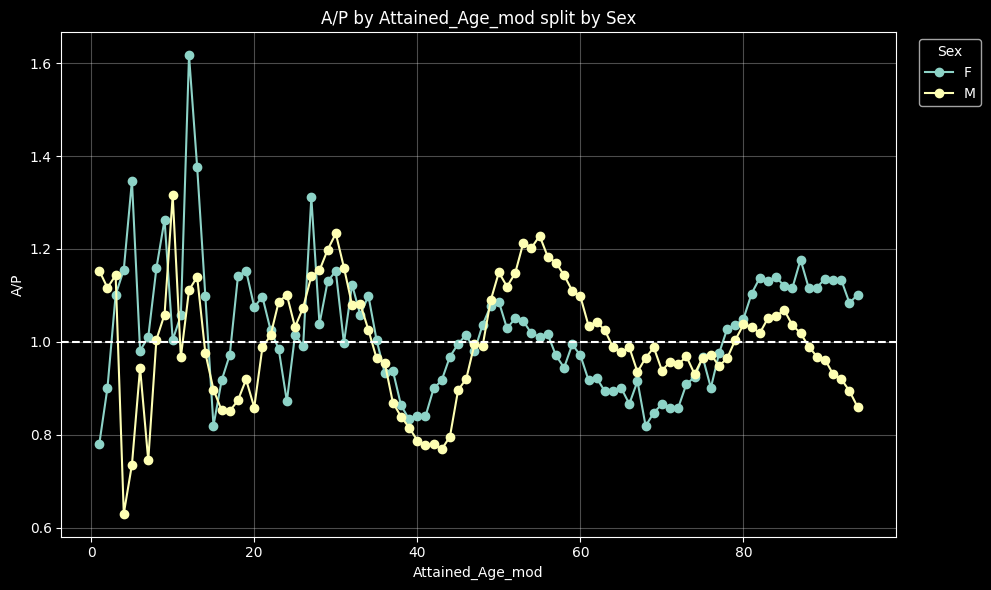

In [48]:
# ============================================================
# GRAPH REVIEW — PREDICTED RATE BY DURATION
# ============================================================

plot_ratio_curves(
    diagnostic_df,
    x_col=ATTAINED_AGE_MOD_COL,
    split_col="Sex",
    numerator_col="Actual_Rate_per_1000",
    denominator_col="Predicted_Rate_per_1000",
    min_expected=MIN_EXPECTED_FOR_MONOTONICITY,
    title="A/P by Attained_Age_mod split by Sex",
    y_label="A/P",
)



In [ ]:
# ============================================================
# GRAPH REVIEW — ACTUAL VS VBT VS PREDICTED
# ============================================================

plot_rate_curves(
    diagnostic_df,
    x_col="Observation_Year",
    split_col="Sex",
    rate_col="Predicted_Rate_per_1000",
    min_expected=MIN_EXPECTED_FOR_MONOTONICITY,
    title="Predicted mortality rate by Observation_Year split by Sex",
)



In [ ]:
# ============================================================
# RESIDUAL HEATMAPS
# ============================================================

residual_heatmap(diagnostic_df, ISSUE_AGE_MOD_COL, ATTAINED_AGE_MOD_COL, value_col="Actual_to_Predicted")


In [ ]:
# ============================================================
# FINAL TESTING SUMMARY TABLE
# ============================================================

summary_points = pd.DataFrame({
    "Item": [
        "Source file",
        "Scoped rows",
        "Selected model",
        "Validation basis",
        "1M face cap applied",
        "Age_Ind filter",
        "Age-basis testing columns",
        "Attained_Age_min",
        "Attained_Age_max",
        "Overall A/P (full refit)",
        "Overall A/VBT (full refit)",
        "Optional development sample fraction",
        "Output Age_Ind",
        "Output Sex",
    ],
    "Value": [
        str(DATA_PATH),
        f"{len(scoped_df):,}",
        SELECTED_MODEL_KEY,
        diagnostic_label,
        str(CAP_FACE_AT_1M),
        str(AGE_IND_KEEP),
        "Issue_Age_mod / Attained_Age_mod used for age-related testing; Age_Ind still segmented explicitly",
        str(ATTAINED_AGE_MIN),
        str(ATTAINED_AGE_MAX),
        round(float(overall_validation.loc[0, "Actual_to_Predicted"]), 6),
        round(float(overall_validation.loc[0, "Actual_to_VBT"]), 6),
        str(DEVELOPMENT_SAMPLE_FRACTION),
        str(OUTPUT_AGE_IND),
        str(OUTPUT_SEX),
    ]
})

display(summary_points)
export_csv(summary_points, "session4_summary_points.csv")


In [ ]:
# ============================================================
# SHEET-STYLE MORTALITY OUTPUTS
# ============================================================

modeled_sheet_pred = build_sheet_style_table(
    scored_df,
    value_col="Predicted_Deaths",
    age_ind_value=OUTPUT_AGE_IND,
    sex_value=OUTPUT_SEX,
    select_period=OUTPUT_SELECT_PERIOD,
    ult_duration=OUTPUT_ULT_DURATION,
    duration_cols=OUTPUT_DURATION_COLUMNS,
    rate_per=OUTPUT_RATE_PER,
    issue_age_min=OUTPUT_ISSUE_AGE_MIN,
    issue_age_max=OUTPUT_ISSUE_AGE_MAX,
)

modeled_sheet_actual = build_sheet_style_table(
    scored_df,
    value_col=ACTUAL_CNT_COL,
    age_ind_value=OUTPUT_AGE_IND,
    sex_value=OUTPUT_SEX,
    select_period=OUTPUT_SELECT_PERIOD,
    ult_duration=OUTPUT_ULT_DURATION,
    duration_cols=OUTPUT_DURATION_COLUMNS,
    rate_per=OUTPUT_RATE_PER,
    issue_age_min=OUTPUT_ISSUE_AGE_MIN,
    issue_age_max=OUTPUT_ISSUE_AGE_MAX,
)

modeled_sheet_vbt = build_sheet_style_table(
    scored_df,
    value_col=EXPECTED_CNT_COL,
    age_ind_value=OUTPUT_AGE_IND,
    sex_value=OUTPUT_SEX,
    select_period=OUTPUT_SELECT_PERIOD,
    ult_duration=OUTPUT_ULT_DURATION,
    duration_cols=OUTPUT_DURATION_COLUMNS,
    rate_per=OUTPUT_RATE_PER,
    issue_age_min=OUTPUT_ISSUE_AGE_MIN,
    issue_age_max=OUTPUT_ISSUE_AGE_MAX,
)

print("Predicted mortality table (rate per 1000)")
display(modeled_sheet_pred)

print("\nActual mortality table (rate per 1000)")
display(modeled_sheet_actual)

print("\n2015 VBT expected table on the same data mix (rate per 1000)")
display(modeled_sheet_vbt)

sheet_stub = f"ageind_{OUTPUT_AGE_IND}_sex_{OUTPUT_SEX}"
export_csv(modeled_sheet_pred, f"session4_modeled_sheet_pred_{sheet_stub}.csv")
export_csv(modeled_sheet_actual, f"session4_modeled_sheet_actual_{sheet_stub}.csv")
export_csv(modeled_sheet_vbt, f"session4_modeled_sheet_vbt_{sheet_stub}.csv")


In [ ]:
# ============================================================
# OPTIONAL BENCHMARK COMPARISON TO A REFERENCE EXCEL SHEET
# ============================================================

if BENCHMARK_XLSX_PATH is not None and BENCHMARK_SHEET_NAME is not None:
    reference_sheet = read_reference_sheet(Path(BENCHMARK_XLSX_PATH), BENCHMARK_SHEET_NAME, max_issue_age=OUTPUT_ISSUE_AGE_MAX)
    benchmark_comparison = compare_to_reference(modeled_sheet_pred, reference_sheet)

    print("Reference sheet")
    display(reference_sheet)

    print("\nLargest modeled-minus-reference differences")
    display(benchmark_comparison.head(25))

    export_csv(reference_sheet, f"session4_reference_sheet_{sheet_stub}.csv")
    export_csv(benchmark_comparison, f"session4_benchmark_comparison_{sheet_stub}.csv")
else:
    print("No benchmark workbook / sheet supplied. Skip this cell unless you want an explicit table-to-table comparison.")


In [ ]:
# Session 4 conclusion paragraph
n_review = int((worst_segments["Flag"] == "Review").sum())
n_issue_monotone_review = int((issue_age_monotonicity["Monotonicity_Flag"] == "Review").sum()) if len(issue_age_monotonicity) else 0
n_duration_monotone_review = int((duration_monotonicity["Monotonicity_Flag"] == "Review").sum()) if len(duration_monotonicity) else 0
overall_ap = float(overall_validation.loc[0, "Actual_to_Predicted"])

session4_conclusion = (
    f"Session 4 conclusion: the selected model {SELECTED_MODEL_KEY} produces an overall A/P of {overall_ap:.4f} "
    f"on the full-data refit. There are {n_review} segment tables currently flagged for review, "
    f"{n_issue_monotone_review} issue-age monotonicity points flagged, and {n_duration_monotone_review} duration monotonicity points flagged "
    f"after applying the credibility floor of {MIN_EXPECTED_FOR_MONOTONICITY:.1f} expected deaths. "
    f"The notebook now supports calibration review, monotonicity review, graph review, and direct sheet-style mortality table production "
    f"without converting Age_Ind to a single basis."
)

print(session4_conclusion)


## Suggested working pattern

1. change the **control panel**
2. run **Session 1** to confirm scope, cap logic, and first-pass A/E review
3. run **Session 2** to review screening, dependence, grouped plan / face diagnostics, and two-way A/E tables
4. run **Session 3** and compare the GAM-style models against the challenger models
5. choose `SELECTED_MODEL_KEY`
6. run **Session 4** to check calibration, monotonicity, graphs, and the sheet-style output
7. if needed later, re-activate a time-based holdout for a separate out-of-sample validation pass
